In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set Visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print('All libraries imported successfully')
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

All libraries imported successfully
Pandas version: 2.1.4
Numpy version: 1.23.5
Matplotlib version: 3.8.4
Seaborn version: 0.13.2


# Dataset 1: Customer Support Tickets

In [2]:
# Load Data
tickets = pd.read_csv('/Users/vishalhooda/Downloads/customer_support_tickets.csv')

print('=' * 70)
print('DATASET: CUSTOMER SUPPORT TICKETS')
print('=' * 70)

print(f"\nShape: {tickets.shape[0]:,} rows * {tickets.shape[1]} columns")

# Display first few rows
print('\nFirst 5 Rows:')
tickets.head()

DATASET: CUSTOMER SUPPORT TICKETS

Shape: 8,469 rows * 17 columns

First 5 Rows:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.000
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.000
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.000


In [3]:
# Column Information
print('=' * 70)
print('COLUMN INFORMATION')
print('=' * 70 + '\n')

# Display all column names
print('All Columns:')
for i, col in enumerate(tickets.columns, 1):
    print(f'{i:2d}. {col}')

# Display data types
print('\nDATA TYPES:')
print(tickets.dtypes)

# Detailed info
print('\nDETAILED INFO:')
tickets.info()

COLUMN INFORMATION

All Columns:
 1. Ticket ID
 2. Customer Name
 3. Customer Email
 4. Customer Age
 5. Customer Gender
 6. Product Purchased
 7. Date of Purchase
 8. Ticket Type
 9. Ticket Subject
10. Ticket Description
11. Ticket Status
12. Resolution
13. Ticket Priority
14. Ticket Channel
15. First Response Time
16. Time to Resolution
17. Customer Satisfaction Rating

DATA TYPES:
Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                   object
First Response Time              object
Time to Resol

In [4]:
# Basic Statistics
print('=' * 70)
print('STATISTICAL SUMMARY')
print('=' * 70)

# Numerical columns
numerical_cols = tickets.select_dtypes(include = [np.number]).columns
if len(numerical_cols) > 0:
    print('NUMERICAL COLUMNS:')
    print(tickets[numerical_cols].describe().T)
    print()

# Categorical columns
categorical_cols = tickets.select_dtypes(include = ['object']).columns
print(f'\nCATEGORICAL COLUMNS: {len(categorical_cols)}')
for col in categorical_cols:
    print(f'{col}: {tickets[col].nunique():,} unique values')

STATISTICAL SUMMARY
NUMERICAL COLUMNS:
                                count     mean      std    min      25%  \
Ticket ID                    8469.000 4235.000 2444.934  1.000 2118.000   
Customer Age                 8469.000   44.027   15.296 18.000   31.000   
Customer Satisfaction Rating 2769.000    2.991    1.407  1.000    2.000   

                                  50%      75%      max  
Ticket ID                    4235.000 6352.000 8469.000  
Customer Age                   44.000   57.000   70.000  
Customer Satisfaction Rating    3.000    4.000    5.000  


CATEGORICAL COLUMNS: 14
Customer Name: 8,028 unique values
Customer Email: 8,320 unique values
Customer Gender: 3 unique values
Product Purchased: 42 unique values
Date of Purchase: 730 unique values
Ticket Type: 5 unique values
Ticket Subject: 16 unique values
Ticket Description: 8,077 unique values
Ticket Status: 3 unique values
Resolution: 2,769 unique values
Ticket Priority: 4 unique values
Ticket Channel: 4 unique val

MISSING VALUES ANALYSIS
                      Column  Missing Count  Missing Percentage
Customer Satisfaction Rating           5700              67.304
          Time to Resolution           5700              67.304
                  Resolution           5700              67.304
         First Response Time           2819              33.286


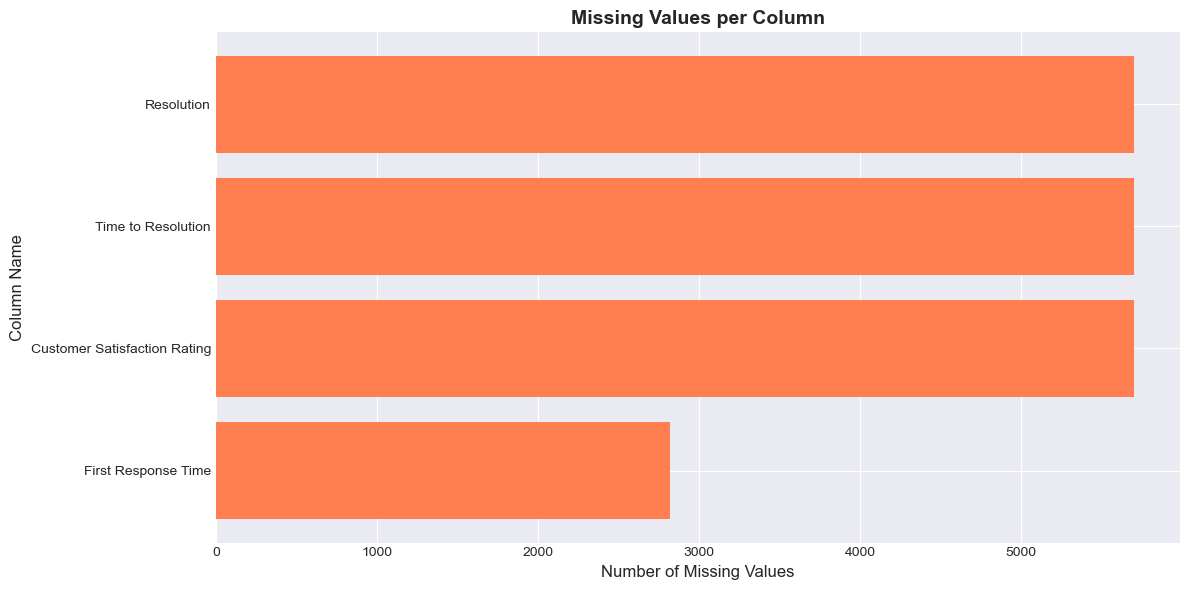

In [5]:
# Missing Values Analysis
print('=' * 70)
print('MISSING VALUES ANALYSIS')
print('=' * 70)

# Calculate missing values
missing_counts = tickets.isnull().sum()
missing_percent = (missing_counts / len(tickets)) * 100

missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing Count': missing_counts.values,
    'Missing Percentage': missing_percent.values
}).sort_values('Missing Count', ascending = False)

# Display only columns with missing values
missing_with_nulls = missing_df[missing_df['Missing Count'] > 0]
if len(missing_with_nulls) > 0:
    print(missing_with_nulls.to_string(index = False))
else:
    print('No missing values found')

# Visualize missing values
plt.figure(figsize = (12, 6))
missing_with_nulls_sorted = missing_with_nulls.sort_values('Missing Count', ascending = True)
plt.barh(missing_with_nulls_sorted['Column'], missing_with_nulls_sorted['Missing Count'], color = 'coral')
plt.xlabel('Number of Missing Values', fontsize = 12)
plt.ylabel('Column Name', fontsize = 12)
plt.title('Missing Values per Column', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

In [6]:
# Duplicate Records
print('=' * 70)
print('DUPLICATE RECORDS')
print('=' * 70)

duplicates = tickets.duplicated().sum()
print(f"Total duplicate rows: {duplicates:,} ({(duplicates / len(tickets) * 100):.2f}%)")

# Check duplicates in Ticket ID
if 'Ticket ID' in tickets.columns:
    duplicate_ids = tickets['Ticket ID'].duplicated().sum()
    print(f'Duplicate Ticket IDs: {duplicate_ids}')

DUPLICATE RECORDS
Total duplicate rows: 0 (0.00%)
Duplicate Ticket IDs: 0


CUSTOMER DEMOGRAPHICS
AGE STATISTICS:
count   8469.000
mean      44.027
std       15.296
min       18.000
25%       31.000
50%       44.000
75%       57.000
max       70.000
Name: Customer Age, dtype: float64

GENDER DISTRIBUTION
Customer Gender
Male      2896
Female    2887
Other     2686
Name: count, dtype: int64

Male: 34.2%
Female: 34.1%
Other: 31.7%


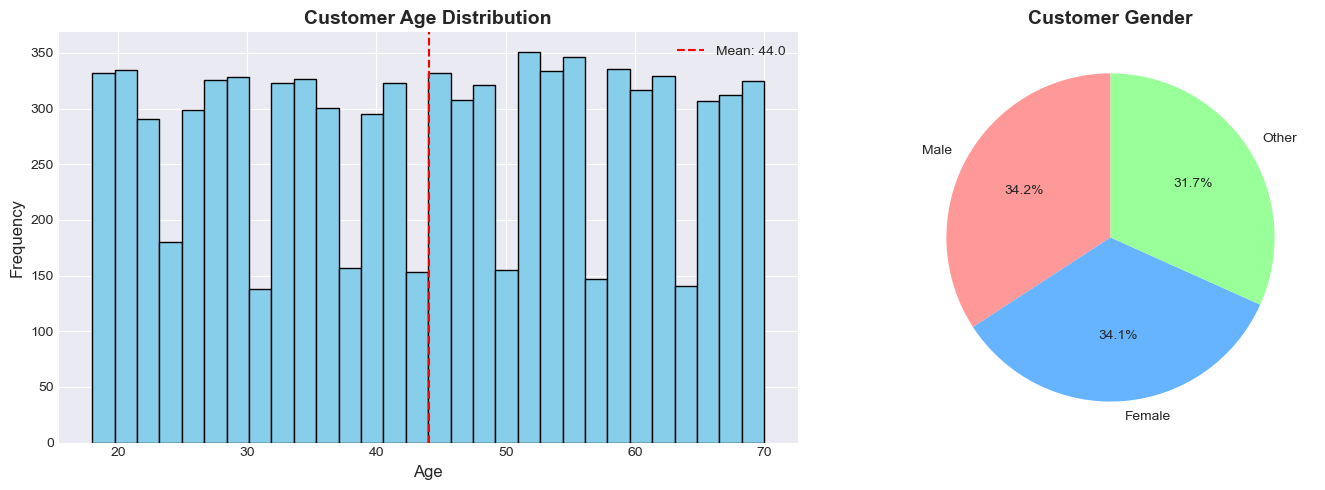

In [7]:
# Customer Demographics
print('=' * 70)
print('CUSTOMER DEMOGRAPHICS')
print('=' * 70)

# Age statistics
if 'Customer Age' in tickets.columns:
    print('AGE STATISTICS:')
    print(tickets['Customer Age'].describe())
    print()

# Gender distribution
if 'Customer Gender' in tickets.columns:
    print('GENDER DISTRIBUTION')
    gender_counts = tickets['Customer Gender'].value_counts()
    print(gender_counts)
    print()

    # Gender percentages
    for gender, count in gender_counts.items():
        pct = (count / len(tickets)) * 100
        print(f'{gender}: {pct:.1f}%')

# Visualize demographics
fig, axes = plt.subplots(1, 2, figsize = (15, 5))

# Age distribution
if 'Customer Age' in tickets.columns:
    axes[0].hist(tickets['Customer Age'].dropna(), bins = 30, color = 'skyblue', edgecolor = 'black')
    axes[0].set_xlabel('Age', fontsize = 12)
    axes[0].set_ylabel('Frequency', fontsize = 12)
    axes[0].set_title('Customer Age Distribution', fontsize = 14, fontweight = 'bold')
    axes[0].axvline(tickets['Customer Age'].mean(), color = 'red', linestyle = '--', label = f"Mean: {tickets['Customer Age'].mean():.1f}")
    axes[0].legend()

# Gender distribution
if 'Customer Gender' in tickets.columns:
    gender_counts = tickets['Customer Gender'].value_counts()
    axes[1].pie(gender_counts, labels = gender_counts.index, autopct = '%1.1f%%', startangle = 90,
                colors = ['#ff9999', '#66b3ff', '#99ff99'])
    axes[1].set_title('Customer Gender', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()

TICKET TYPE ANALYSIS
TICKET TYPES:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Refund request: 20.7%
Technical issue: 20.6%
Cancellation request: 20.0%
Product inquiry: 19.4%
Billing inquiry: 19.3%


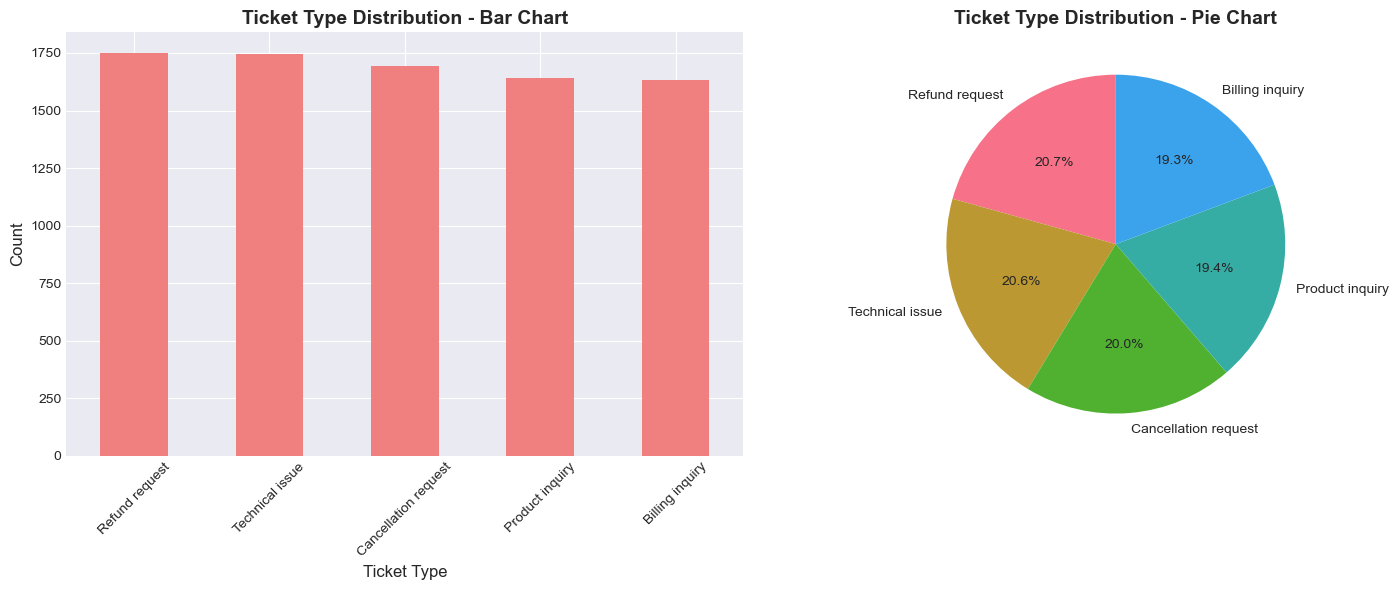

In [8]:
# Ticket Type Analysis
print('=' * 70)
print('TICKET TYPE ANALYSIS')
print('=' * 70)

if 'Ticket Type' in tickets.columns:
    print('TICKET TYPES:')
    ticket_types = tickets['Ticket Type'].value_counts()
    print(ticket_types)
    print()

    # Percentages
    for ticket_type, count in ticket_types.items():
        pct = (count / len(tickets)) * 100
        print(f"{ticket_type}: {pct:.1f}%")

    # Visulization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 6))

    # Bar chart
    ticket_types.plot(kind = 'bar', ax = ax1, color = 'lightcoral')
    ax1.set_title('Ticket Type Distribution - Bar Chart', fontsize = 14, fontweight = 'bold')
    ax1.set_xlabel('Ticket Type', fontsize = 12)
    ax1.set_ylabel('Count', fontsize = 12)
    ax1.tick_params(axis = 'x', rotation = 45)

    # Pie chart
    ax2.pie(ticket_types, labels = ticket_types.index, autopct = '%1.1f%%', startangle = 90)
    ax2.set_title('Ticket Type Distribution - Pie Chart', fontsize = 14, fontweight = 'bold')

    plt.tight_layout()
    plt.show()

TICKET SUBJECT ANALYSIS
TOP 10 TICKET SUBJECTS:
Ticket Subject
Refund request           576
Software bug             574
Product compatibility    567
Delivery problem         561
Hardware issue           547
Battery life             542
Network problem          539
Installation support     530
Product setup            529
Payment issue            526
Name: count, dtype: int64



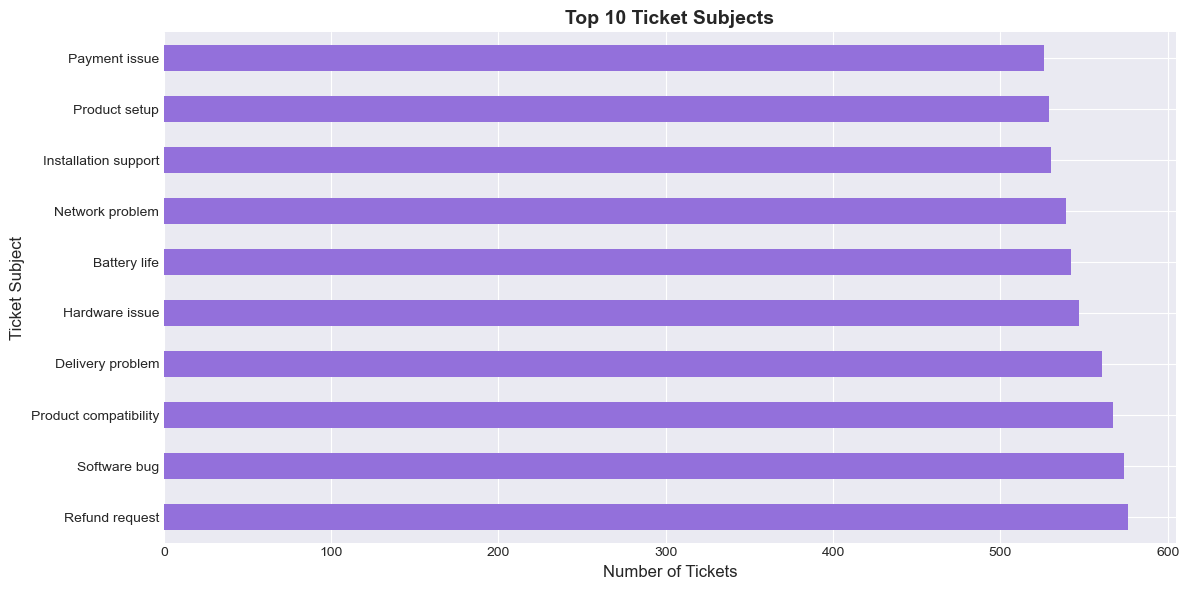

In [9]:
# Ticket Subject Analysis
print('=' * 70)
print('TICKET SUBJECT ANALYSIS')
print('=' * 70)

if 'Ticket Subject' in tickets.columns:
    print('TOP 10 TICKET SUBJECTS:')
    subject_counts = tickets['Ticket Subject'].value_counts().head(10)
    print(subject_counts)
    print()

    # Visualization
    plt.figure(figsize = (12, 6))
    subject_counts.plot(kind = 'barh', color = 'mediumpurple')
    plt.xlabel('Number of Tickets', fontsize = 12)
    plt.ylabel('Ticket Subject', fontsize = 12)
    plt.title('Top 10 Ticket Subjects', fontsize = 14, fontweight = 'bold')
    plt.tight_layout()
    plt.show()

TICKET PRIORITY ANALYSIS
TICKETS PRIORITY LEVELS:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Medium : 25.9%
Critical : 25.1%
High : 24.6%
Low : 24.4%


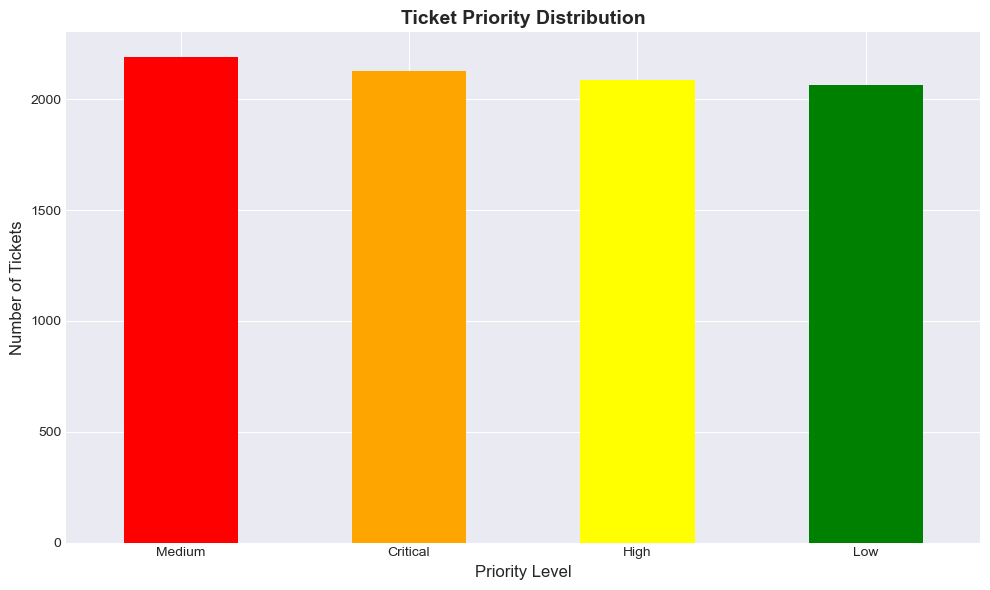

In [10]:
# Ticket Priority Analysis
print('=' * 70)
print('TICKET PRIORITY ANALYSIS')
print('=' * 70)

if 'Ticket Priority' in tickets.columns:
    print('TICKETS PRIORITY LEVELS:')
    priority_counts = tickets['Ticket Priority'].value_counts()
    print(priority_counts)
    print()

    # Percentages
    for priority, count in priority_counts.items():
        pct = (count / len(tickets)) * 100
        print(f"{priority} : {pct:.1f}%")

    # Visualization
    plt.figure(figsize = (10, 6))
    priority_counts.plot(kind = 'bar', color = ['red', 'orange', 'yellow', 'green'])
    plt.title('Ticket Priority Distribution', fontsize = 14, fontweight = 'bold')
    plt.xlabel('Priority Level', fontsize = 12)
    plt.ylabel('Number of Tickets', fontsize = 12)
    plt.xticks(rotation = 0)
    plt.tight_layout()
    plt.show()

TICKET CHANNEL ANALYSIS
Ticket Channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

Email: 25.3%
Phone: 25.2%
Social media: 25.0%
Chat: 24.5%


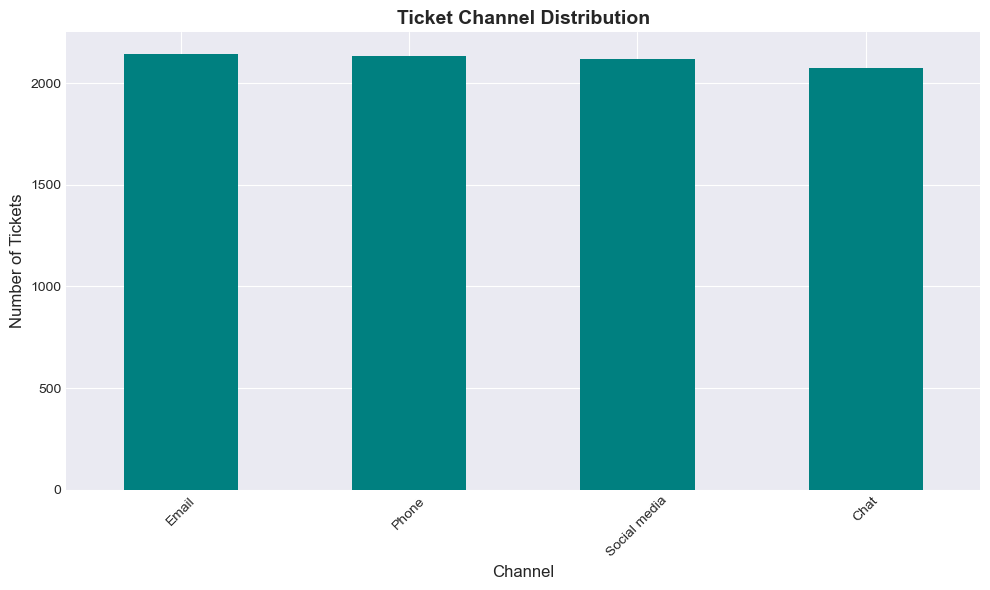

In [11]:
# Ticket Channel Analysis
print('=' * 70)
print('TICKET CHANNEL ANALYSIS')
print('=' * 70)

if 'Ticket Channel' in tickets.columns:
    channel_counts = tickets['Ticket Channel'].value_counts()
    print(channel_counts)
    print()

    # Percentages
    for channel, count in channel_counts.items():
        pct = (count / len(tickets)) * 100
        print(f"{channel}: {pct:.1f}%")

    # Visualization
    plt.figure(figsize = (10, 6))
    channel_counts.plot(kind = 'bar', color = 'teal')
    plt.title('Ticket Channel Distribution', fontsize = 14, fontweight = 'bold')
    plt.xlabel('Channel', fontsize = 12)
    plt.ylabel('Number of Tickets', fontsize = 12)
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

PRODUCT ANALYSIS
Top 10 Products with Most Tickets:
Product Purchased
Canon EOS              240
GoPro Hero             228
Nest Thermostat        225
Philips Hue Lights     221
Amazon Echo            221
LG Smart TV            219
Sony Xperia            217
Roomba Robot Vacuum    216
Apple AirPods          213
LG OLED                213
Name: count, dtype: int64



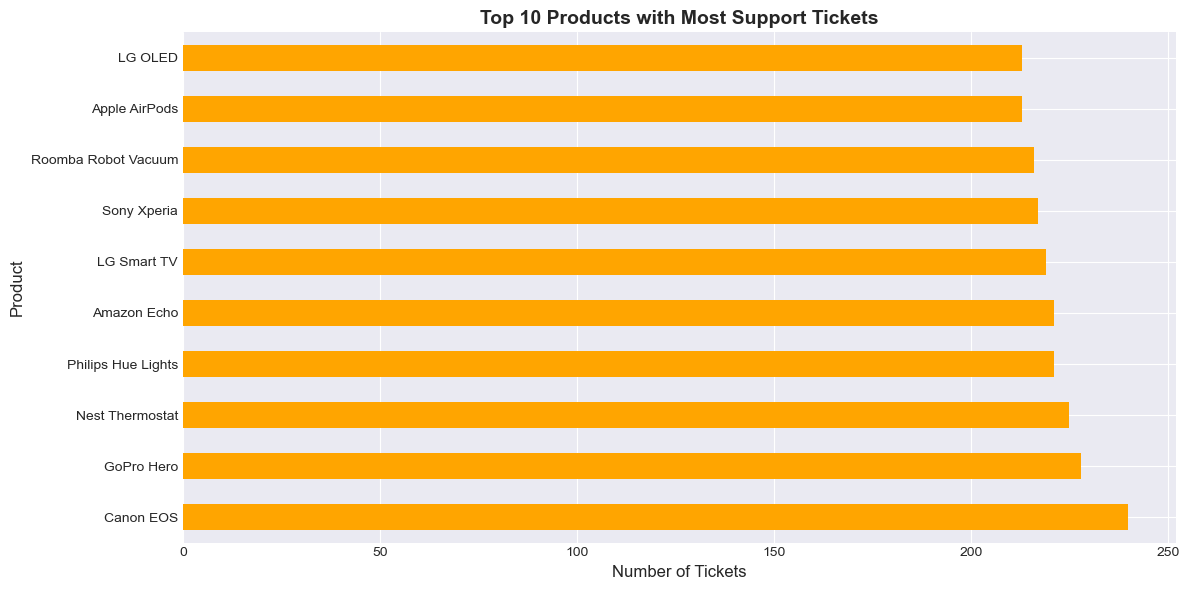

In [12]:
# Product Analysis
print('=' * 70)
print('PRODUCT ANALYSIS')
print('=' * 70)

if 'Product Purchased' in tickets.columns:
    print('Top 10 Products with Most Tickets:')
    product_counts = tickets['Product Purchased'].value_counts().head(10)
    print(product_counts)
    print()

    # Visualization
    plt.figure(figsize = (12, 6))
    product_counts.plot(kind = 'barh', color = 'orange')
    plt.xlabel('Number of Tickets', fontsize = 12)
    plt.ylabel('Product', fontsize = 12)
    plt.title('Top 10 Products with Most Support Tickets', fontsize = 14, fontweight = 'bold')
    plt.tight_layout()
    plt.show()

CUSTOMER SATISFACTION RATING ANALYSIS
count   2769.000
mean       2.991
std        1.407
min        1.000
25%        2.000
50%        3.000
75%        4.000
max        5.000
Name: Customer Satisfaction Rating, dtype: float64

RATING DISTRIBUTION
Customer Satisfaction Rating
1.000    553
2.000    549
3.000    580
4.000    543
5.000    544
Name: count, dtype: int64

AVERAGE SATISFACTION RATING: 2.99/ 5.0

1 stars: 20.0%
2 stars: 19.8%
3 stars: 20.9%
4 stars: 19.6%
5 stars: 19.6%


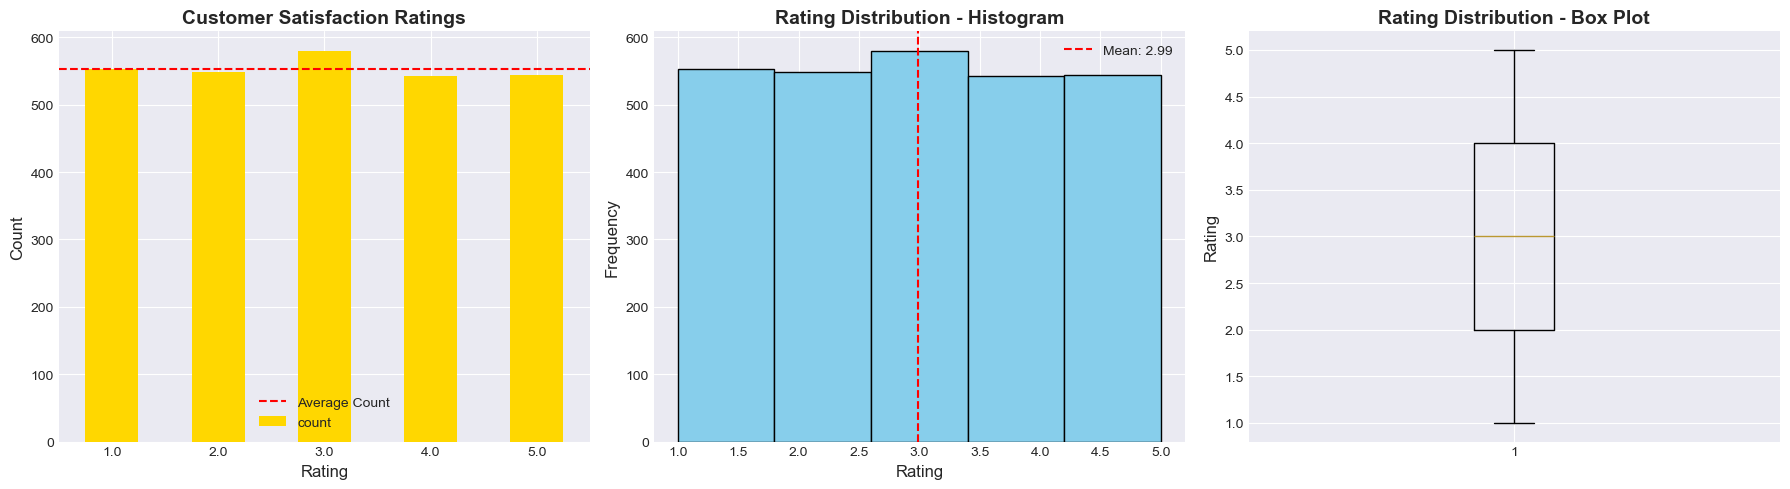

In [13]:
# Customer Satisfcation Rating Analysis
print('=' * 70)
print('CUSTOMER SATISFACTION RATING ANALYSIS')
print('=' * 70)

if 'Customer Satisfaction Rating' in tickets.columns:
    # Basic Statistics
    print(tickets['Customer Satisfaction Rating'].describe())
    print()

    # Count by rating
    print('RATING DISTRIBUTION')
    rating_counts = tickets['Customer Satisfaction Rating'].value_counts().sort_index()
    print(rating_counts)
    print()

    # Average rating
    avg_rating = tickets['Customer Satisfaction Rating'].mean()
    print(f"AVERAGE SATISFACTION RATING: {avg_rating:.2f}/ 5.0")
    print()

    # Percentage of each rating
    total_rating = tickets['Customer Satisfaction Rating'].notna().sum()
    for rating in sorted(tickets['Customer Satisfaction Rating'].dropna().unique()):
        count = (tickets['Customer Satisfaction Rating'] == rating).sum()
        pct = (count / total_rating) * 100
        print(f"{rating:.0f} stars: {pct:.1f}%")

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize = (18, 5))

    # Bar chart
    rating_counts.plot(kind = 'bar', ax = axes[0], color = 'gold')
    axes[0].set_title('Customer Satisfaction Ratings', fontsize = 14, fontweight = 'bold')
    axes[0].set_xlabel('Rating', fontsize = 12)
    axes[0].set_ylabel('Count', fontsize = 12)
    axes[0].axhline(y = rating_counts.mean(), color = 'r', linestyle = '--', label = 'Average Count')
    axes[0].legend()

    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation = 0)

    # Histogram
    axes[1].hist(tickets['Customer Satisfaction Rating'].dropna(), bins = 5, color = 'skyblue', edgecolor = 'black')
    axes[1].set_title('Rating Distribution - Histogram', fontsize = 14, fontweight = 'bold')
    axes[1].set_xlabel('Rating', fontsize = 12)
    axes[1].set_ylabel('Frequency', fontsize = 12)
    axes[1].axvline(avg_rating, color = 'red', linestyle = '--', label = f"Mean: {avg_rating:.2f}")
    axes[1].legend()

    # Box plot
    axes[2].boxplot(tickets['Customer Satisfaction Rating'].dropna())
    axes[2].set_title('Rating Distribution - Box Plot', fontsize = 14, fontweight = 'bold')
    axes[2].set_ylabel('Rating', fontsize = 12)

    plt.tight_layout()
    plt.show()

RESPONSE TIME ANALYSIS
FIRST RESONSE TIME:
Total records: 5,650
Missing values: 2,819

TIME TO RESOLUTION:
Total records: 2,769
Missing value: 5,700

RESOLUTINO TIME STATISTICS (HOURS):
count   1404.000
mean       7.578
std        5.597
min        0.000
25%        3.000
50%        6.342
75%       11.354
max       23.467
Name: Resolution_Hours, dtype: float64



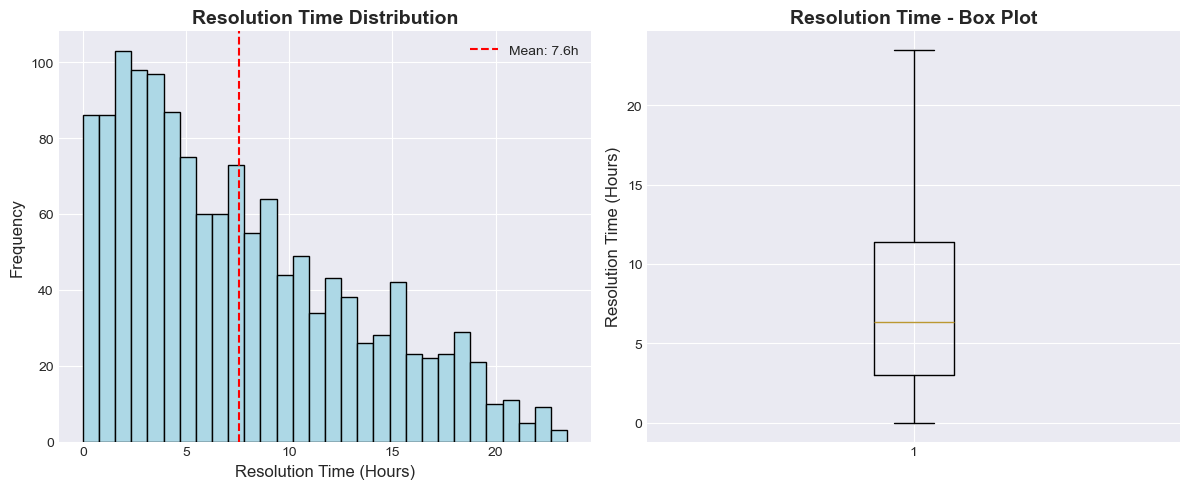

In [14]:
# Response Time Analysis
print('=' * 70)
print('RESPONSE TIME ANALYSIS')
print('=' * 70)

if 'First Response Time' in tickets.columns:
    # Convert to datetime if not already
    tickets['First Response Time'] = pd.to_datetime(tickets['First Response Time'], errors = 'coerce')

    print('FIRST RESONSE TIME:')
    print(f"Total records: {tickets['First Response Time'].notna().sum():,}")
    print(f"Missing values: {tickets['First Response Time'].isna().sum():,}")
    print()

if 'Time to Resolution' in tickets.columns:
    # Convert to datetime if not already
    tickets['Time to Resolution'] = pd.to_datetime(tickets['Time to Resolution'], errors = 'coerce')

    print('TIME TO RESOLUTION:')
    print(f"Total records: {tickets['Time to Resolution'].notna().sum():,}")
    print(f"Missing value: {tickets['Time to Resolution'].isna().sum():,}")
    print()

# Calculate resolution time in hours (if both columns exist)
if 'First Response Time' in tickets.columns and 'Time to Resolution' in tickets.columns:
    tickets['Resolution_Hours'] = (tickets['Time to Resolution'] - tickets['First Response Time']).dt.total_seconds() / 3600

    # Only analyze non-negative values
    valid_resolution = tickets[tickets['Resolution_Hours'] >= 0]['Resolution_Hours']

    if len(valid_resolution) > 0:
        print('RESOLUTINO TIME STATISTICS (HOURS):')
        print(valid_resolution.describe())
        print()

        # Visualization
        plt.figure(figsize = (12, 5))
        
        plt.subplot(1, 2, 1)
        plt.hist(valid_resolution, bins = 30, color = 'lightblue', edgecolor = 'black')
        plt.xlabel('Resolution Time (Hours)', fontsize = 12)
        plt.ylabel('Frequency', fontsize = 12)
        plt.title('Resolution Time Distribution', fontsize = 14, fontweight = 'bold')
        plt.axvline(valid_resolution.mean(), color = 'red', linestyle = '--', label = f"Mean: {valid_resolution.mean():.1f}h")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.boxplot(valid_resolution)
        plt.ylabel('Resolution Time (Hours)', fontsize = 12)
        plt.title('Resolution Time - Box Plot', fontsize = 14, fontweight = 'bold')

        plt.tight_layout()
        plt.show()

TEXT ANALYSIS - TICKET DESCRIPTION
DESCRIPTION LENGTH STATISTICS (CHARACTERS):
count   8469.000
mean     289.822
std       43.594
min      151.000
25%      273.000
50%      298.000
75%      318.000
max      397.000
Name: Description_Length, dtype: float64

DESCRIPTION WORD COUNT STATISTICS:
count   8469.000
mean      46.467
std        8.462
min       21.000
25%       43.000
50%       49.000
75%       52.000
max       63.000
Name: Description_Words, dtype: float64



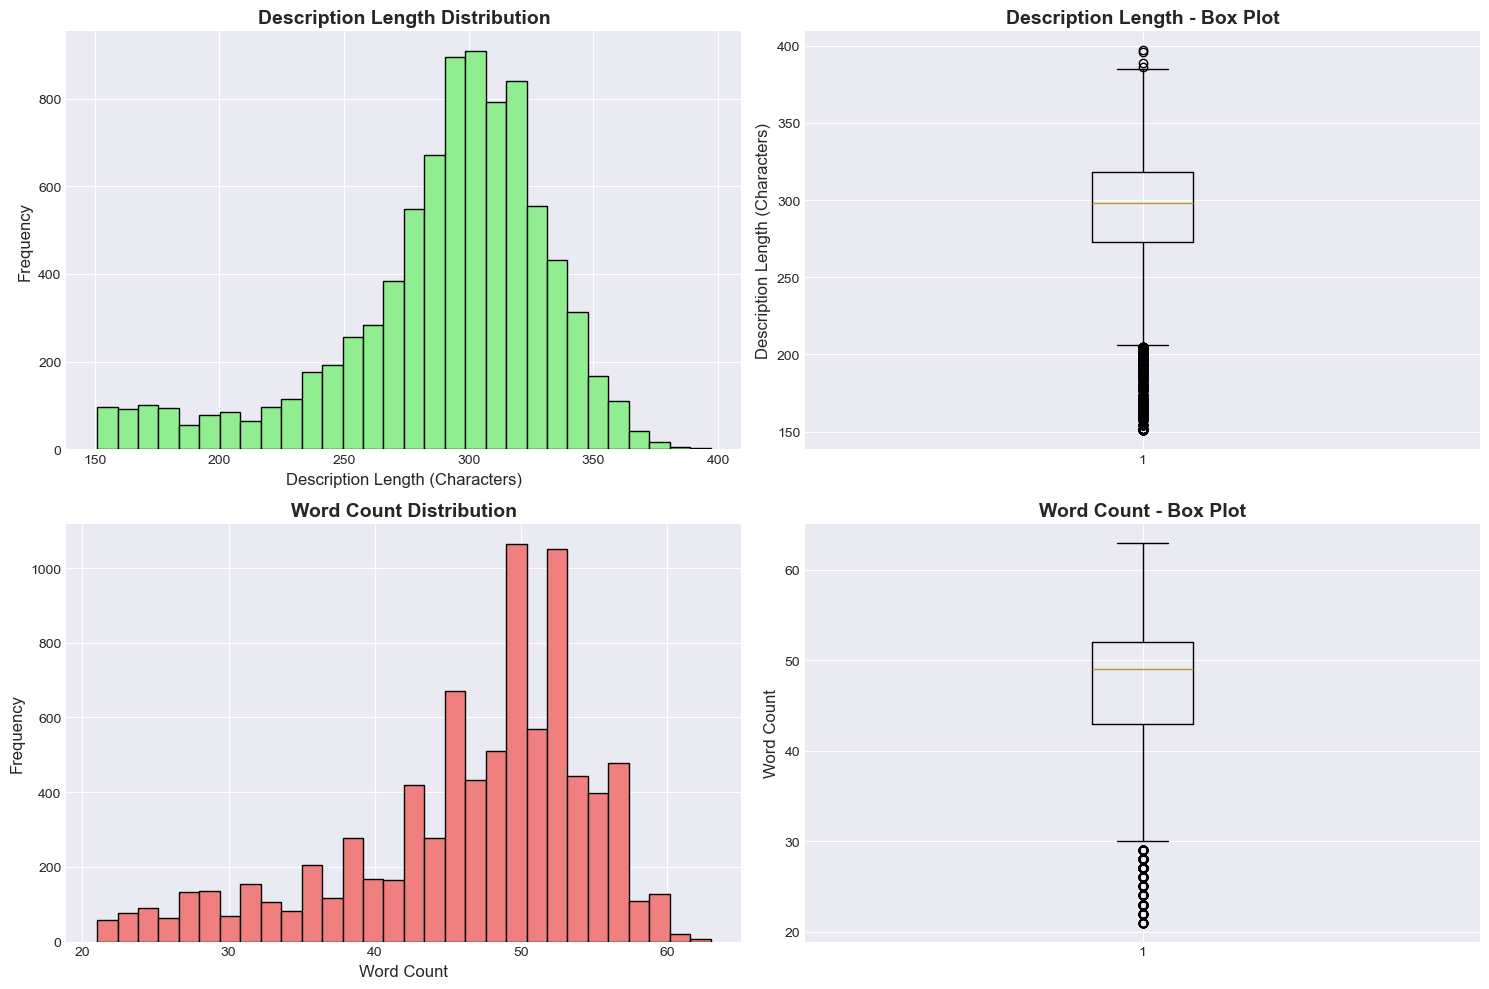

In [15]:
# Text Analysis - Ticket Description
print('=' * 70)
print('TEXT ANALYSIS - TICKET DESCRIPTION')
print('=' * 70)

if 'Ticket Description' in tickets.columns:
    # Calculate text length
    tickets['Description_Length'] = tickets['Ticket Description'].fillna('').str.len()
    tickets['Description_Words'] = tickets['Ticket Description'].fillna('').str.split().str.len()

    print('DESCRIPTION LENGTH STATISTICS (CHARACTERS):')
    print(tickets['Description_Length'].describe())
    print()

    print('DESCRIPTION WORD COUNT STATISTICS:')
    print(tickets['Description_Words'].describe())
    print()

    # Visualizations
    fig, axes = plt.subplots(2, 2, figsize = (15, 10))

    # Character length histogram
    axes[0, 0].hist(tickets['Description_Length'], bins = 30, color = 'lightgreen', edgecolor = 'black')
    axes[0, 0].set_xlabel('Description Length (Characters)', fontsize = 12)
    axes[0, 0].set_ylabel('Frequency', fontsize = 12)
    axes[0, 0].set_title('Description Length Distribution', fontsize = 14, fontweight = 'bold')

    # Character length box plot
    axes[0, 1].boxplot(tickets['Description_Length'])
    axes[0, 1].set_ylabel('Description Length (Characters)', fontsize = 12)
    axes[0, 1].set_title('Description Length - Box Plot', fontsize = 14, fontweight = 'bold')

    # Word count histogram
    axes[1, 0].hist(tickets['Description_Words'], bins = 30, color = 'lightcoral', edgecolor = 'black')
    axes[1, 0].set_xlabel('Word Count', fontsize = 12)
    axes[1, 0].set_ylabel('Frequency', fontsize = 12)
    axes[1, 0].set_title('Word Count Distribution', fontsize = 14, fontweight = 'bold')

    # Word count box plot
    axes[1, 1].boxplot(tickets['Description_Words'])
    axes[1, 1].set_ylabel('Word Count', fontsize = 12)
    axes[1, 1].set_title('Word Count - Box Plot', fontsize = 14, fontweight = 'bold')

    plt.tight_layout()
    plt.show()

CROSS-ANALYSIS
PRIORITY vs STATUS:
Ticket Status    Closed  Open  Pending Customer Response
Ticket Priority                                         
Critical            726   692                        711
High                705   704                        676
Low                 644   696                        723
Medium              694   727                        771



<Figure size 1200x600 with 0 Axes>

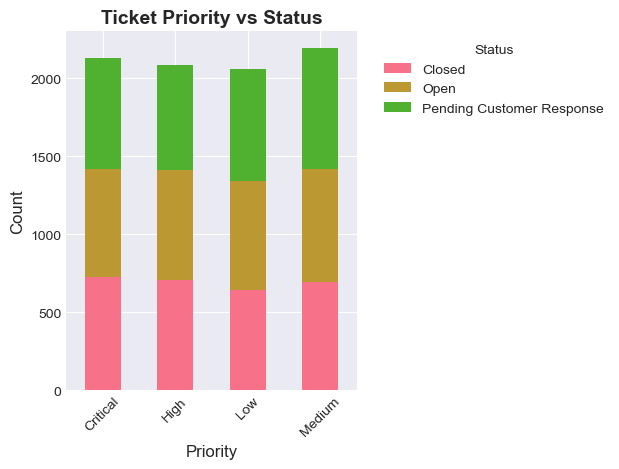

PRIORITY vs CHANNEL:
Ticket Channel   Chat  Email  Phone  Social media
Ticket Priority                                  
Critical          504    571    526           528
High              517    504    512           552
Low               501    525    499           538
Medium            551    543    595           503



<Figure size 1200x600 with 0 Axes>

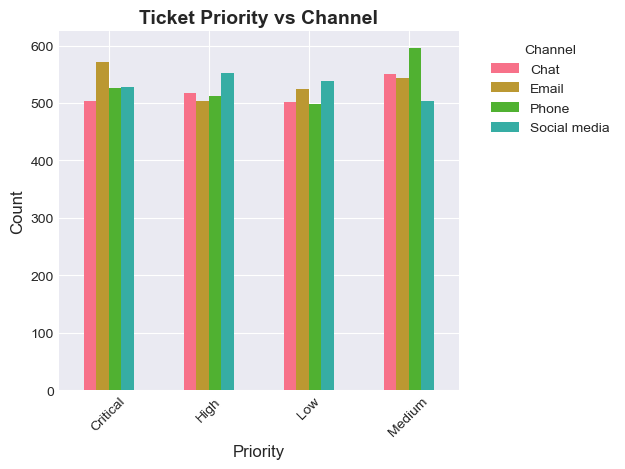

TICKET TYPE vs SATISFACTION RATING:
                      mean  count
Ticket Type                      
Billing inquiry      3.028    544
Cancellation request 3.029    516
Product inquiry      3.017    533
Refund request       2.935    596
Technical issue      2.959    580



<Figure size 1000x600 with 0 Axes>

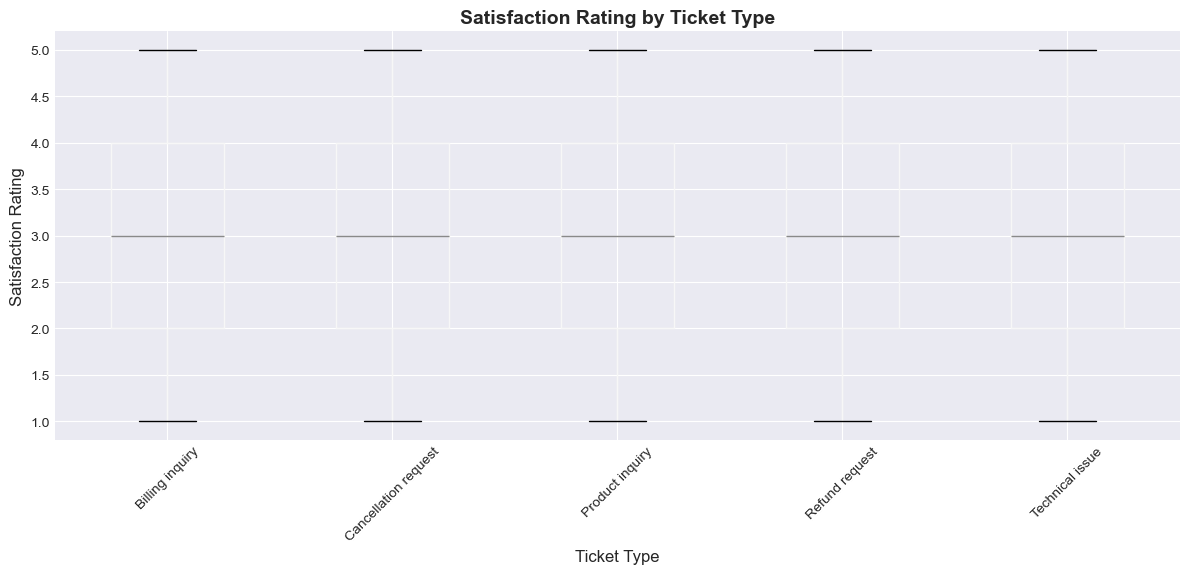

In [16]:
# Cross-Analysis - Priority vs Status
print('=' * 70)
print('CROSS-ANALYSIS')
print('=' * 70)

if 'Ticket Priority' in tickets.columns and 'Ticket Status' in tickets.columns:
    print('PRIORITY vs STATUS:')
    priority_status = pd.crosstab(tickets['Ticket Priority'], tickets['Ticket Status'])
    print(priority_status)
    print()

    # Visualization
    plt.figure(figsize = (12, 6))
    priority_status.plot(kind = 'bar', stacked = True)
    plt.title('Ticket Priority vs Status', fontsize = 14, fontweight = 'bold')
    plt.xlabel('Priority', fontsize = 12)
    plt.ylabel('Count', fontsize = 12)
    plt.legend(title = 'Status', bbox_to_anchor = (1.05, 1), loc = 'upper left')
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

# Priority vs Channel
if 'Ticket Priority' in tickets.columns and 'Ticket Channel' in tickets.columns:
    print('PRIORITY vs CHANNEL:')
    priority_channel = pd.crosstab(tickets['Ticket Priority'], tickets['Ticket Channel'])
    print(priority_channel)
    print()

    # Visualization
    plt.figure(figsize = (12, 6))
    priority_channel.plot( kind = 'bar', stacked = False)
    plt.title('Ticket Priority vs Channel', fontsize = 14, fontweight = 'bold')
    plt.xlabel('Priority', fontsize = 12)
    plt.ylabel('Count', fontsize = 12)
    plt.legend(title = 'Channel', bbox_to_anchor = (1.05, 1), loc = 'upper left')
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

# Type vs Satisfaction
if 'Ticket Type' in tickets.columns and 'Customer Satisfaction Rating' in tickets.columns:
    print('TICKET TYPE vs SATISFACTION RATING:')
    type_satisfaction = tickets.groupby('Ticket Type')['Customer Satisfaction Rating'].agg(['mean', 'count'])
    print(type_satisfaction)
    print()

    # Visualization
    plt.figure(figsize = (10, 6))
    tickets.boxplot(column = 'Customer Satisfaction Rating', by = 'Ticket Type', figsize = (12, 6))
    plt.title('Satisfaction Rating by Ticket Type', fontsize = 14, fontweight = 'bold')
    plt.suptitle('')
    plt.xlabel('Ticket Type' , fontsize = 12)
    plt.ylabel('Satisfaction Rating', fontsize = 12)
    plt.xticks(rotation = 45)
    plt.tight_layout()
    plt.show()

CORRELATION ANALYSIS
CORRELATIONS BETWEEN NUMERCIAL VARIABLES:
                              Customer Age  Customer Satisfaction Rating  \
Customer Age                         1.000                        -0.004   
Customer Satisfaction Rating        -0.004                         1.000   
Resolution_Hours                     0.004                         0.020   
Description_Length                  -0.006                        -0.014   
Description_Words                   -0.005                        -0.010   

                              Resolution_Hours  Description_Length  \
Customer Age                             0.004              -0.006   
Customer Satisfaction Rating             0.020              -0.014   
Resolution_Hours                         1.000              -0.014   
Description_Length                      -0.014               1.000   
Description_Words                       -0.003               0.913   

                              Description_Words  
Customer 

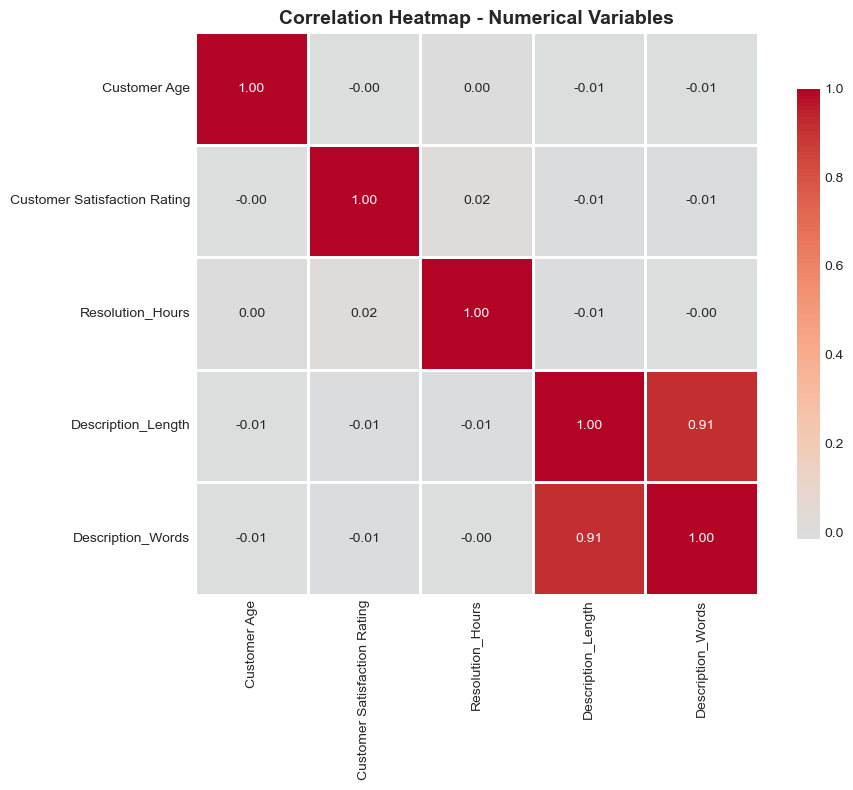

In [17]:
# Correlation Anaysis
print('=' * 70)
print('CORRELATION ANALYSIS')
print('=' * 70)

# Select only numerical columns for correlation
numerical_cols = tickets.select_dtypes(include = [np.number]).columns
numerical_cols = [col for col in numerical_cols if col not in ['Ticket ID']] # Exclude ID

if len(numerical_cols) > 1:
    print('CORRELATIONS BETWEEN NUMERCIAL VARIABLES:')

    # Calculate correlation matrix
    correlation_matrix = tickets[numerical_cols].corr()
    print(correlation_matrix)
    print()

    # Visualization
    plt.figure(figsize = (10, 8))
    sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', center = 0, square = True,
                linewidths = 1, cbar_kws = {"shrink": 0.8}, fmt = '.2f')
    plt.title('Correlation Heatmap - Numerical Variables', fontsize = 14, fontweight = 'bold')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numerical columns for correlation analysis')

DATE ANALYSIS
Purchase Date Range:
Earliest: 2020-01-01 00:00:00
Latest: 2021-12-30 00:00:00
Purchases by Year:
Purchase Year
2020    4236
2021    4233
Name: count, dtype: int64

Purchases by Month:
Purchase Month
1     736
2     715
3     672
4     718
5     701
6     678
7     727
8     691
9     696
10    735
11    704
12    696
Name: count, dtype: int64



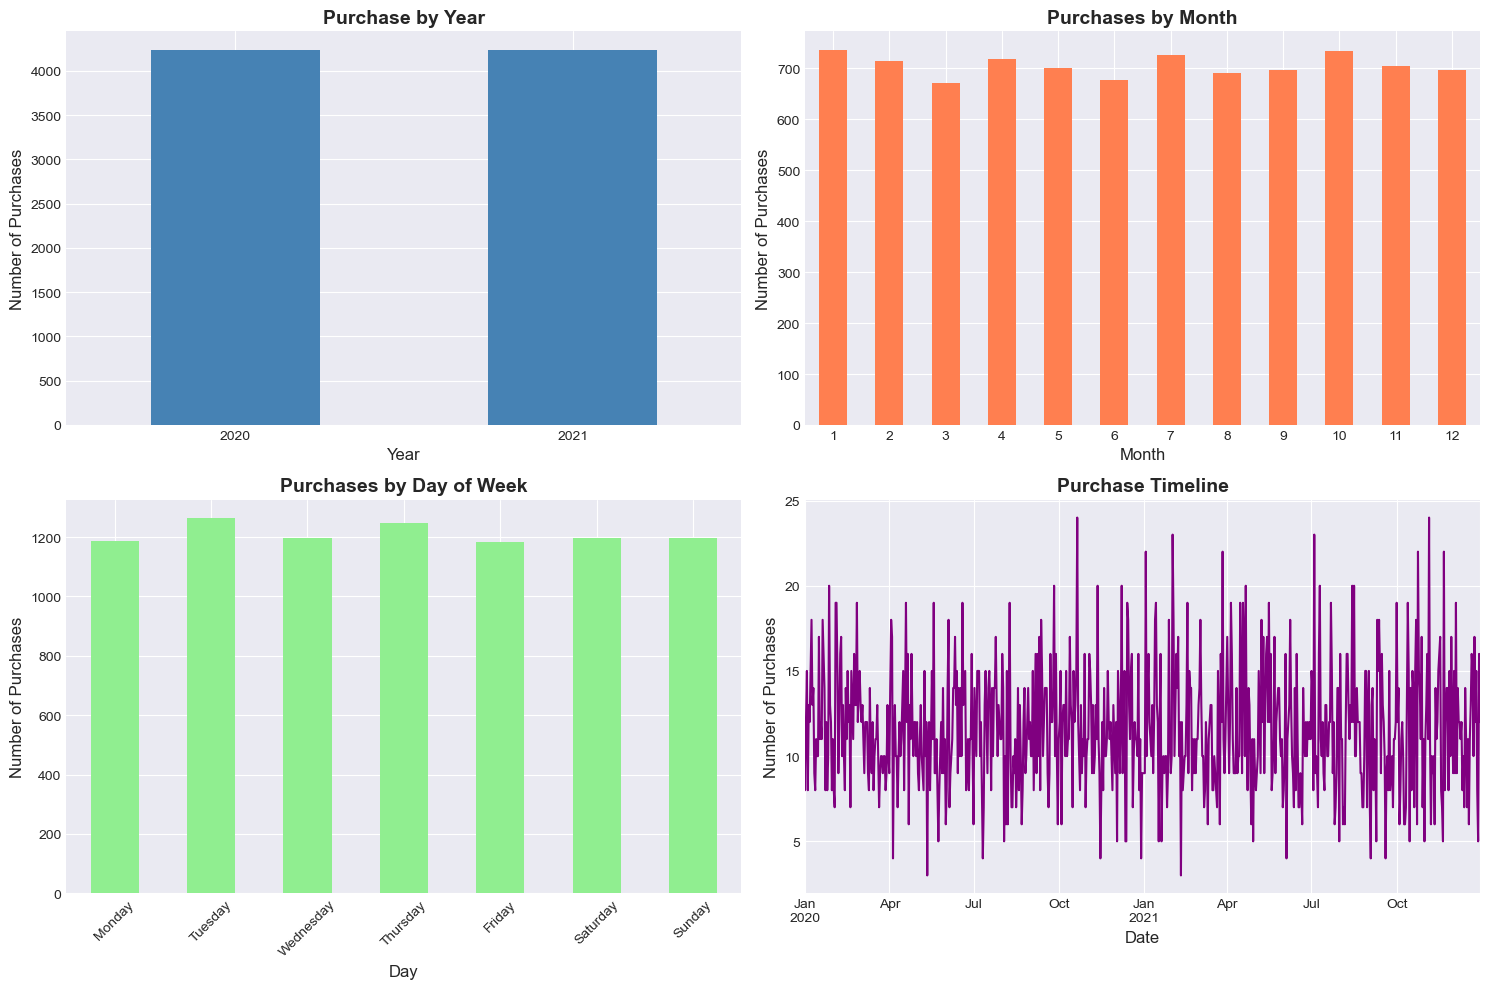

In [18]:
# Date Analysis
print('=' * 70)
print('DATE ANALYSIS')
print('=' * 70)

if 'Date of Purchase' in tickets.columns:
    # Convert to datetime
    tickets['Date of Purchase'] = pd.to_datetime(tickets['Date of Purchase'], errors = 'coerce')

    # Extract date components
    tickets['Purchase Year'] = tickets['Date of Purchase'].dt.year
    tickets['Purchase Month'] = tickets['Date of Purchase'].dt.month
    tickets['Purchase Day'] = tickets['Date of Purchase'].dt.day
    tickets['Purchase Day of Week'] = tickets['Date of Purchase'].dt.day_name()

    print('Purchase Date Range:')
    print(f"Earliest: {tickets['Date of Purchase'].min()}")
    print(f"Latest: {tickets['Date of Purchase'].max()}")

    # Year distribution
    print("Purchases by Year:")
    year_counts = tickets['Purchase Year'].value_counts().sort_index()
    print(year_counts)
    print()

    # Month distribution
    print('Purchases by Month:')
    month_counts = tickets['Purchase Month'].value_counts().sort_index()
    print(month_counts)
    print()

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize = (15, 10))

    # Purchase by Year
    year_counts.plot(kind = 'bar', ax = axes[0, 0], color = 'steelblue')
    axes[0, 0].set_title('Purchase by Year', fontsize = 14, fontweight = 'bold')
    axes[0, 0].set_xlabel('Year', fontsize = 12)
    axes[0, 0].set_ylabel('Number of Purchases', fontsize = 12)
    axes[0, 0].tick_params(axis = 'x', rotation = 0)

    # Purchase by Month
    month_counts.plot(kind = 'bar', ax = axes[0, 1], color = 'coral')
    axes[0, 1].set_title('Purchases by Month', fontsize = 14, fontweight = 'bold')
    axes[0, 1].set_xlabel('Month', fontsize = 12)
    axes[0, 1].set_ylabel('Number of Purchases', fontsize = 12)
    axes[0, 1].tick_params(axis = 'x', rotation = 0)

    # Purcahses by day of week
    dow_counts = tickets['Purchase Day of Week'].value_counts()
    dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dow_counts = dow_counts.reindex([d for d in dow_order if d in dow_counts.index])
    dow_counts.plot(kind = 'bar', ax = axes[1, 0], color = 'lightgreen')
    axes[1, 0].set_title('Purchases by Day of Week', fontsize = 14, fontweight = 'bold')
    axes[1, 0].set_xlabel('Day', fontsize = 12)
    axes[1, 0].set_ylabel('Number of Purchases', fontsize = 12)
    axes[1, 0].tick_params(axis = 'x', rotation = 45)

    # Timeline 
    purchase_timeline = tickets.groupby('Date of Purchase').size()
    purchase_timeline.plot(ax = axes[1, 1], color = 'purple')
    axes[1, 1].set_title('Purchase Timeline', fontsize = 14, fontweight = 'bold')
    axes[1, 1].set_xlabel('Date', fontsize = 12)
    axes[1, 1].set_ylabel('Number of Purchases', fontsize = 12)

    plt.tight_layout()
    plt.show()

In [19]:
# Summary Statistics
print('=' * 70)
print('COMPRENSIVE SUMMARY')
print('=' * 70)

summary_stats = {'Total Tickets': len(tickets), 
                 'Unique Customers': tickets['Customer Email'].nunique() if 'Customer Email' in tickets.columns else 'N/A',
                 'Date Range': f"{tickets['Date of Purchase'].min()} to {tickets['Date of Purchase'].max()}" if 'Date of Purchase'
                 in tickets.columns else 'N/A',
                 'Avg Customer Age': f"{tickets['Customer Age'].mean():.1f}" if 'Customer Age' in tickets.columns else 'N/A',
                 'Most Common Ticket Type': tickets['Ticket Type'].mode()[0] if 'Ticket Type' in tickets.columns else 'N/A',
                 'Most Common Priority': tickets['Ticket Priority'].mode()[0] if 'Ticket Priority' in tickets.columns else 'N/A',
                 'Most Common Channel': tickets['Ticket Channel'].mode()[0] if 'Ticket Channel' in tickets.columns else 'N/A',
                 'Avg Satisfaction': f"{tickets['Customer Satisfaction Rating'].mean():.2f}/5.0" if 'Customer Satisfaction Rating'
                 in tickets.columns else 'N/A',
                 'Missing Values': tickets.isnull().sum().sum(),
                 'Duplicate Records': tickets.duplicated().sum()
}

print('Key Metrics:')
for key, value in summary_stats.items():
    print(f"{key}: {value}")

COMPRENSIVE SUMMARY
Key Metrics:
Total Tickets: 8469
Unique Customers: 8320
Date Range: 2020-01-01 00:00:00 to 2021-12-30 00:00:00
Avg Customer Age: 44.0
Most Common Ticket Type: Refund request
Most Common Priority: Medium
Most Common Channel: Email
Avg Satisfaction: 2.99/5.0
Missing Values: 25619
Duplicate Records: 0


In [20]:
# Key Findings & Insights
print('=' * 70)
print('KEY FINDINS & INSIGHTS')
print('=' * 70)

print('Data Quality:')
print(f" Total missing values: {tickets.isnull().sum().sum():,}")
print(f"Columns with missing data: {(tickets.isnull().sum() > 0).sum()}")
print(f"Duplicate records: {tickets.duplicated().sum():,}")
print()

print('Customer Insights:')
if 'Customer Age' in tickets.columns:
    print(f"Average Customer Age: {tickets['Customer Age'].mean():.1f} years")
    print(f"Age Range: {tickets['Customer Age'].min():} - {tickets['Customer Age'].max():}")

if 'Customer Gender' in tickets.columns:
    most_common_gender = tickets['Customer Gender'].mode()[0]
    print(f"Most common gender: {most_common_gender}")
print()

print('Ticket Insights:')
if 'Ticket Type' in tickets.columns:
    print(f"Most common ticket type: {tickets['Ticket Type'].mode()[0]}")
if 'Ticket Priority' in tickets.columns:
    print(f"Most common priority: {tickets['Ticket Priority'].mode()[0]}")
if 'Ticket Status' in tickets.columns:
    print(f"Most common status: {tickets['Ticket Status'].mode()[0]}")
if 'Ticket Channel' in tickets.columns:
    print(f"Preferred channel: {tickets['Ticket Channel'].mode()[0]}")
print()

print("Satisfaction:")
if 'Customer Satisfaction Rating' in tickets.columns:
    avg_rating = tickets['Customer Satisfaction Rating'].mean()
    print(f"Average rating: {avg_rating:.2f}/5.0")
    
    low_ratings = (tickets['Customer Satisfaction Rating'] <= 2).sum()
    low_pct = (low_ratings / tickets['Customer Satisfaction Rating'].notna().sum()) * 100
    print(f"Low ratings (≤2): {low_ratings} ({low_pct:.1f}%)")
    
    high_ratings = (tickets['Customer Satisfaction Rating'] >= 4).sum()
    high_pct = (high_ratings / tickets['Customer Satisfaction Rating'].notna().sum()) * 100
    print(f"High ratings (≥4): {high_ratings} ({high_pct:.1f}%)")
print()

print("Products:")
if 'Product Purchased' in tickets.columns:
    top_product = tickets['Product Purchased'].value_counts().index[0]
    top_product_count = tickets['Product Purchased'].value_counts().iloc[0]
    print(f"Product with most tickets: {top_product} ({top_product_count} tickets)")

KEY FINDINS & INSIGHTS
Data Quality:
 Total missing values: 25,619
Columns with missing data: 5
Duplicate records: 0

Customer Insights:
Average Customer Age: 44.0 years
Age Range: 18 - 70
Most common gender: Male

Ticket Insights:
Most common ticket type: Refund request
Most common priority: Medium
Most common status: Pending Customer Response
Preferred channel: Email

Satisfaction:
Average rating: 2.99/5.0
Low ratings (≤2): 1102 (39.8%)
High ratings (≥4): 1087 (39.3%)

Products:
Product with most tickets: Canon EOS (240 tickets)


In [21]:
# Save Processed Data (Optional)
print('=' * 70)
print('SAVE ANALYSIS')
print('=' * 70)

# Save the explored dataset with new features
output_path = '/Users/vishalhooda/Documents/Intelligent-Customer-Support/data/processed/tickets_explored.csv'

try:
    tickets.to_csv(output_path, index = False)
    print(f"Dataset saved to: {output_path}")
except:
    print("Count not save file. Check if the directory exists.")

print('\n' + '=' * 70)
print('DATA EXPLORATION OF DATASET 1 COMPLETE')
print('=' * 70)

SAVE ANALYSIS
Dataset saved to: /Users/vishalhooda/Documents/Intelligent-Customer-Support/data/processed/tickets_explored.csv

DATA EXPLORATION OF DATASET 1 COMPLETE


In [22]:
# Load Spam Dataset
print('\n' + '=' * 70)
print('SPAM MESSAGES DATASET EXPLORATION')
print('=' * 70 + '\n')

# Load the spam dataset
spam_file_path = '/Users/vishalhooda/Documents/Intelligent-Customer-Support/data/raw/spam.csv'

# Load with encoding to handle special characters
spam = pd.read_csv(spam_file_path, encoding = 'latin-1')
print('Spam dataset loaded successfully')
print(f"Dataset shape: {spam.shape}")


SPAM MESSAGES DATASET EXPLORATION

Spam dataset loaded successfully
Dataset shape: (5572, 5)


In [23]:
# Initial Data Inspection

print('\n' +  '=' * 70)
print('INITIAL DATA INSPECTION')
print('=' * 70 + '\n')

# Display first few rows
print('First 10 rows (RAW DATA):')
print(spam.head(10))
print('\n' + '=' * 70)

# Display last few rows
print('\nLast 5 rows:')
print(spam.tail())
print('\n' + '=' * 70)

# Column information
print('\nCOLUMN NAMES:')
for i, col in enumerate(spam, 1):
    print(f"{i}. {col}")

print('\n' + '=' * 70)

# Data types and info
print('\nDATASET INFO:')
spam.info()


INITIAL DATA INSPECTION

First 10 rows (RAW DATA):
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   
5  spam  FreeMsg Hey there darling it's been 3 week's n...        NaN   
6   ham  Even my brother is not like to speak with me. ...        NaN   
7   ham  As per your request 'Melle Melle (Oru Minnamin...        NaN   
8  spam  WINNER!! As a valued network customer you have...        NaN   
9  spam  Had your mobile 11 months or more? U R entitle...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN  

In [24]:
# Data Cleaning - Handle Unnamed Columns
print('\n' + '=' * 70)
print('DATA CLEANING')
print('=' * 70 + '\n')

# Check for unnamed columns
unnamed_cols = [col for col in spam.columns if 'Unnamed' in col]
print(f"Found {len(unnamed_cols)} unnamed columns: {unnamed_cols}")

# Check how many non-null values in unnamed columns
print('\nNon-null counts in unnamed columns:')
for col in unnamed_cols:
    non_null = spam[col].notna().sum()
    print(f"{col}: {non_null} non-null values ({(non_null / len(spam) * 100):.2f}%)")

# These unnamed columns have very few values, likely erros in CSV, We'll drop them
print('\nDropping unnamed columns...')
spam = spam.drop(columns = unnamed_cols)
print(f"Unnamed columns dropped")

# Rename columns to meaningfull names
print('\nRenaming columns..')
spam.columns = ['label', 'message']
print('New column names:', list(spam.columns))

print('\nCLEANED DATA:')
print(spam.head())

print('\n' + '=' * 70)
print(f"Data cleaned! New shape: {spam.shape}")
print('=' * 70)


DATA CLEANING

Found 3 unnamed columns: ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Non-null counts in unnamed columns:
Unnamed: 2: 50 non-null values (0.90%)
Unnamed: 3: 12 non-null values (0.22%)
Unnamed: 4: 6 non-null values (0.11%)

Dropping unnamed columns...
Unnamed columns dropped

Renaming columns..
New column names: ['label', 'message']

CLEANED DATA:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Data cleaned! New shape: (5572, 2)


In [25]:
# Missing Values Analysis
print('\n' + '=' * 70)
print('MISSING VALUES ANALYSIS')
print('=' * 70 + '\n')

# Check for missing values in cleaned data
missing_counts = spam.isnull().sum()
missing_percent = (missing_counts / len(spam)) * 100

missing_df = pd.DataFrame({
    'Column' : missing_counts.index,
    'Missing Count' : missing_counts.values,
    'Missing Percentage' : missing_percent.values
})

print(missing_df.to_string(index = False))

if missing_counts.sum() == 0:
    print('\nNo missing values in cleaned dataset')
else:
    print(f"\nTotal missing values: {missing_counts.sum()}")

# Check for duplicates
duplicates = spam.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates} ({(duplicates / len(spam) * 100):.2f}%)")

if duplicates > 0:
    print(f"Note: {duplicates} duplicate messages found")


MISSING VALUES ANALYSIS

 Column  Missing Count  Missing Percentage
  label              0               0.000
message              0               0.000

No missing values in cleaned dataset

Duplicate Rows: 403 (7.23%)
Note: 403 duplicate messages found



LABEL DISTRIBUTION ANALYSIS

MESSAGE CLASSIFICATION:
label
ham     4825
spam     747
Name: count, dtype: int64

HAM: 4,825 messages (86.59%)
SPAM: 747 messages (13.41%)

SPAM RATE: 13.41%
HAM RATE: 86.59%

CLASS BALANCE:
Imbalance Ratio: 6.46:1
• SMOTE (oversampling)
• Class weights
• Stratified sampling


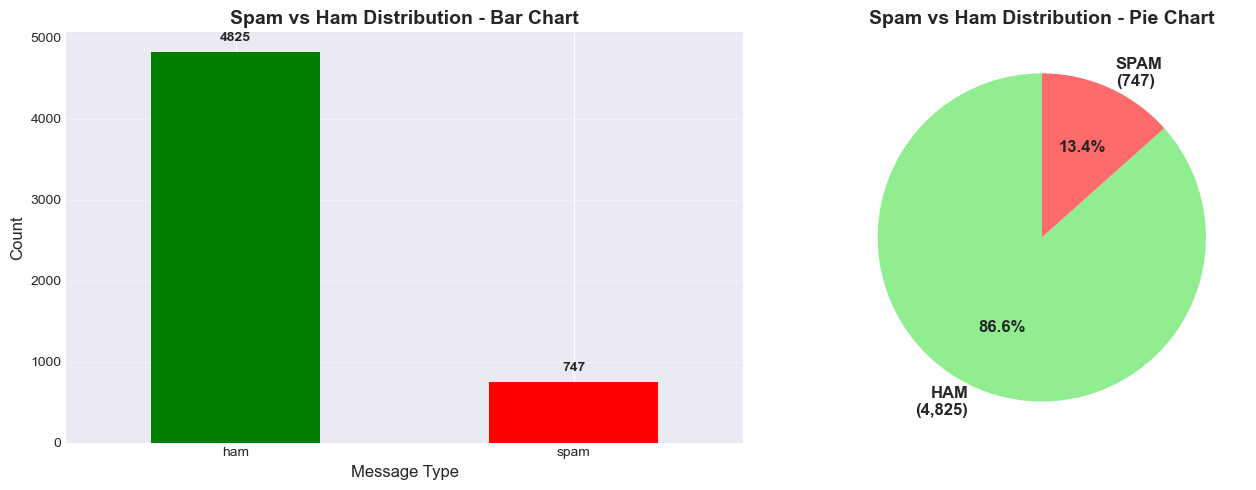

In [26]:
# Label Distribution Analysis
print('\n' + '=' * 70)
print('LABEL DISTRIBUTION ANALYSIS')
print('=' * 70 + '\n')

# Count spam vs ham
label_counts = spam['label'].value_counts()
print('MESSAGE CLASSIFICATION:')
print(label_counts)
print()

# Calculate percentages
total_messages = len(spam)
for label, count in label_counts.items():
    percentage = (count / total_messages) * 100
    print(f"{label.upper()}: {count:,} messages ({percentage:.2f}%)")

# Calculate spam rate
spam_count = label_counts.get('spam', 0)
spam_rate = (spam_count / total_messages) * 100
print(f"\nSPAM RATE: {spam_rate:.2f}%")
print(f"HAM RATE: {100 - spam_rate:.2f}%")

# Check class balance
print(f"\nCLASS BALANCE:")
ratio = label_counts.max() / label_counts.min()
print(f"Imbalance Ratio: {ratio:.2f}:1")
if ratio > 3:
    print('WARNING: Highly imbalanced dataset! Consider using:')
    print("• SMOTE (oversampling)")
    print('• Class weights')
    print('• Stratified sampling')
else:
    print('Dataset is reasonably balanced')

# Visualization
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Bar Chart
label_counts.plot(kind = 'bar', ax = axes[0], color = ['green', 'red'])
axes[0].set_title('Spam vs Ham Distribution - Bar Chart', fontsize = 14, fontweight = 'bold')
axes[0].set_xlabel('Message Type', fontsize = 12)
axes[0].set_ylabel('Count', fontsize = 12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation = 0)
axes[0].grid(axis = 'y', alpha = 0.3)

# Add count labels on bars
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha = 'center', va = 'bottom', fontweight = 'bold')

# Pie Chart
colors = ['#90EE90', '#FF6B6B']  # Light green for ham, light red for spam
axes[1].pie(label_counts, labels = [f'{label.upper()}\n({count:,})' for label, count in label_counts.items()],
            autopct = '%1.1f%%', startangle = 90, colors = colors, textprops = {'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Spam vs Ham Distribution - Pie Chart', fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()



MESSAGE LENGTH ANALYSIS

MESSAGE LENGTH STATISTICS (Characters):
count   5572.000
mean      80.119
std       59.691
min        2.000
25%       36.000
50%       61.000
75%      121.000
max      910.000
Name: message_length, dtype: float64

WORD COUNT STATISTICS:
count   5572.000
mean      15.494
std       11.329
min        1.000
25%        7.000
50%       12.000
75%       23.000
max      171.000
Name: word_count, dtype: float64

STATISTICS BY MESSAGE TYPE:

CHARACTER LENGTH:
         count    mean    std    min     25%     50%     75%     max
label                                                               
ham   4825.000  71.024 58.016  2.000  33.000  52.000  92.000 910.000
spam   747.000 138.866 29.183 13.000 132.500 149.000 157.000 224.000

WORD COUNT:
         count   mean    std   min    25%    50%    75%     max
label                                                          
ham   4825.000 14.201 11.425 1.000  7.000 11.000 19.000 171.000
spam   747.000 23.851  5.812 2.000 22.0

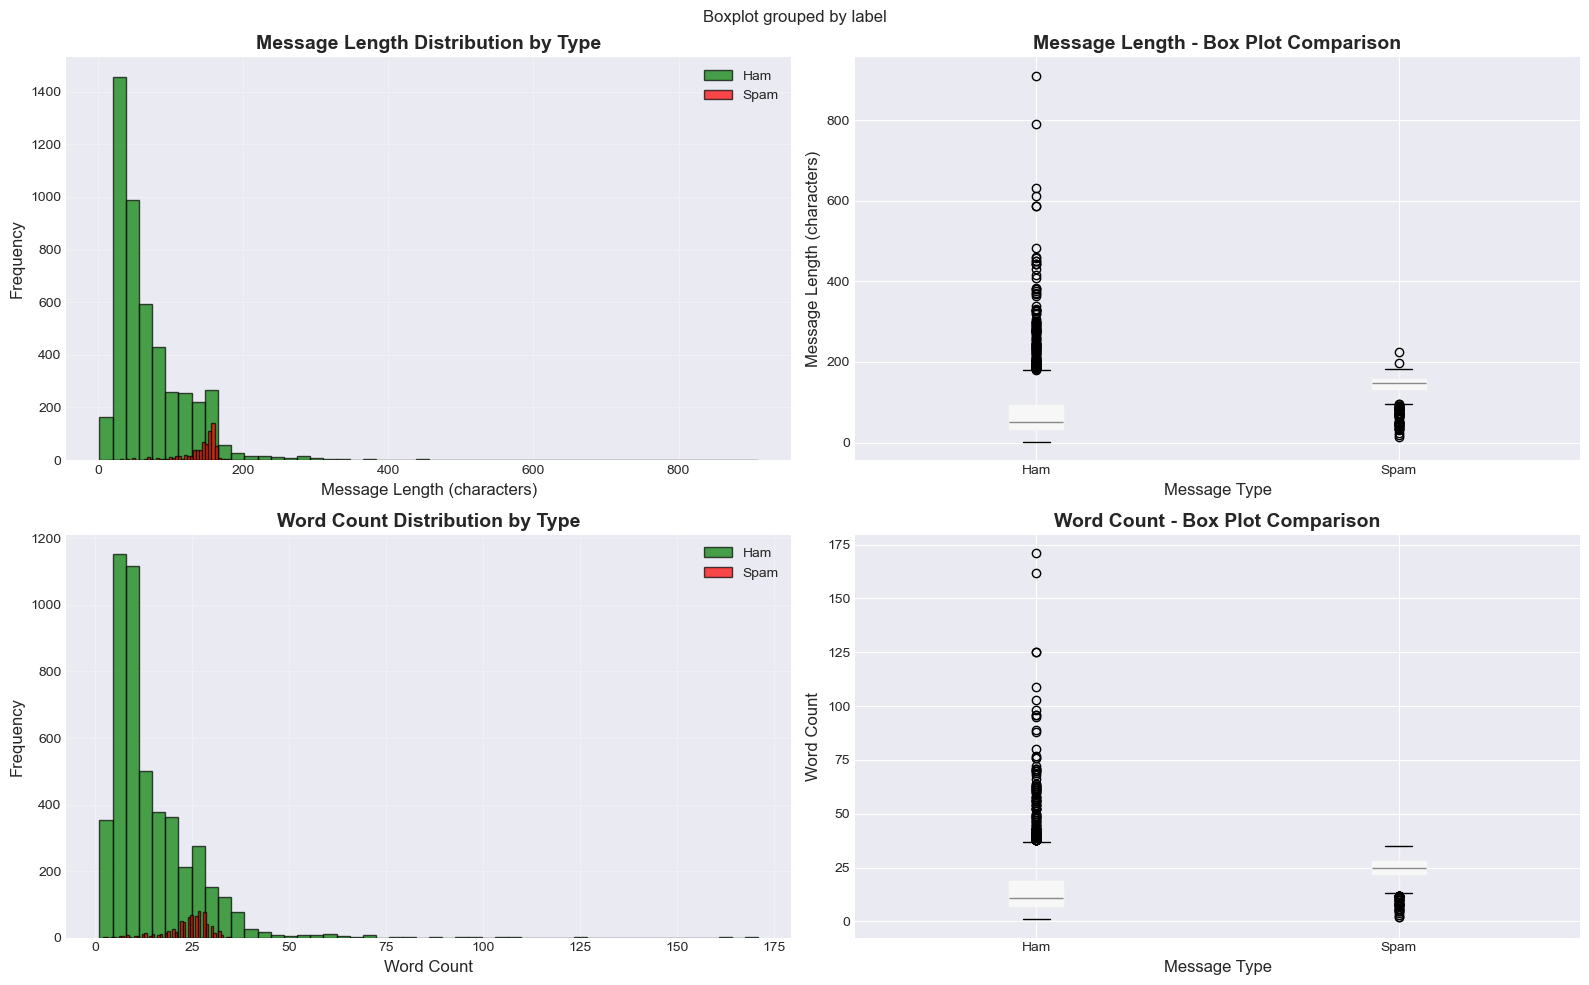

In [27]:
# Message Length Analysis
print('\n' + '=' * 70)
print('MESSAGE LENGTH ANALYSIS')
print('=' * 70 + '\n')

# Calculate message length
spam['message_length'] = spam['message'].str.len()
spam['word_count'] = spam['message'].str.split().str.len()

# Overall statistics
print('MESSAGE LENGTH STATISTICS (Characters):')
print(spam['message_length'].describe())
print()

print('WORD COUNT STATISTICS:')
print(spam['word_count'].describe())
print()

# Statistics by label
print('STATISTICS BY MESSAGE TYPE:\n')
print('CHARACTER LENGTH:')
print(spam.groupby('label')['message_length'].describe())
print()

print('WORD COUNT:')
print(spam.groupby('label')['word_count'].describe())
print()

# Compare averages
print('AVERAGE COMPARISON:')
avg_stats = spam.groupby('label')[['message_length', 'word_count']].mean()
print(avg_stats)
print()

ham_avg_len = spam[spam['label'] == 'ham']['message_length'].mean()
spam_avg_len = spam[spam['label'] == 'spam']['message_length'].mean()
print(f"INSIGHT: Spam messages are {(spam_avg_len / ham_avg_len - 1) * 100:.1f}% {'longer' if spam_avg_len > ham_avg_len else 'shorter'} than ham messages on average")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize = (16, 10))

# Character length - Histogram comparison
axes[0, 0].hist(spam[spam['label'] == 'ham']['message_length'], bins = 50, alpha = 0.7,
                label = 'Ham', color = 'green', edgecolor = 'black')
axes[0, 0].hist(spam[spam['label'] == 'spam']['message_length'], bins = 50, alpha = 0.7,
                label = 'Spam', color = 'red', edgecolor = 'black')
axes[0, 0].set_xlabel('Message Length (characters)', fontsize = 12)
axes[0, 0].set_ylabel('Frequency', fontsize = 12)
axes[0, 0].set_title('Message Length Distribution by Type', fontsize = 14, fontweight = 'bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha = 0.3)

# Character length - Box plot
spam.boxplot(column = 'message_length', by = 'label', ax = axes[0, 1], patch_artist = True)
axes[0, 1].set_title('Message Length - Box Plot Comparison', fontsize = 14, fontweight = 'bold')
axes[0, 1].set_xlabel('Message Type', fontsize = 12)
axes[0, 1].set_ylabel('Message Length (characters)', fontsize = 12)
plt.sca(axes[0, 1])
plt.xticks([1, 2], ['Ham', 'Spam'])

# Word count - Histogram comparison
axes[1, 0].hist(spam[spam['label'] == 'ham']['word_count'], bins = 50, alpha = 0.7,
                label = 'Ham', color = 'green', edgecolor = 'black')
axes[1, 0].hist(spam[spam['label'] == 'spam']['word_count'], bins = 50, alpha = 0.7,
                label = 'Spam', color = 'red', edgecolor = 'black')
axes[1, 0].set_xlabel('Word Count', fontsize = 12)
axes[1, 0].set_ylabel('Frequency', fontsize = 12)
axes[1, 0].set_title('Word Count Distribution by Type', fontsize = 14, fontweight = 'bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha = 0.3)

# Word count - Box plot
spam.boxplot(column = 'word_count', by = 'label', ax = axes[1, 1], patch_artist = True)
axes[1, 1].set_title('Word Count - Box Plot Comparison', fontsize = 14, fontweight = 'bold')
axes[1, 1].set_xlabel('Message Type', fontsize = 12)
axes[1, 1].set_ylabel('Word Count', fontsize = 12)
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Ham', 'Spam'])

plt.tight_layout()
plt.show()


TEXT CONTENT ANALYSIS

SAMPLE HAM MESSAGES:
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got a...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my brother is not like to speak with me. They treat me like aids patent.

SAMPLE SPAM MESSAGES:
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entr...

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it s...

3. WINNER!! As a valued network customer you have been selected to receivea å£900 prize reward! To clai...

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera f...

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6day...

CHARACTER PATTERNS BY TYPE:

HAM MESSAGES:
Contai

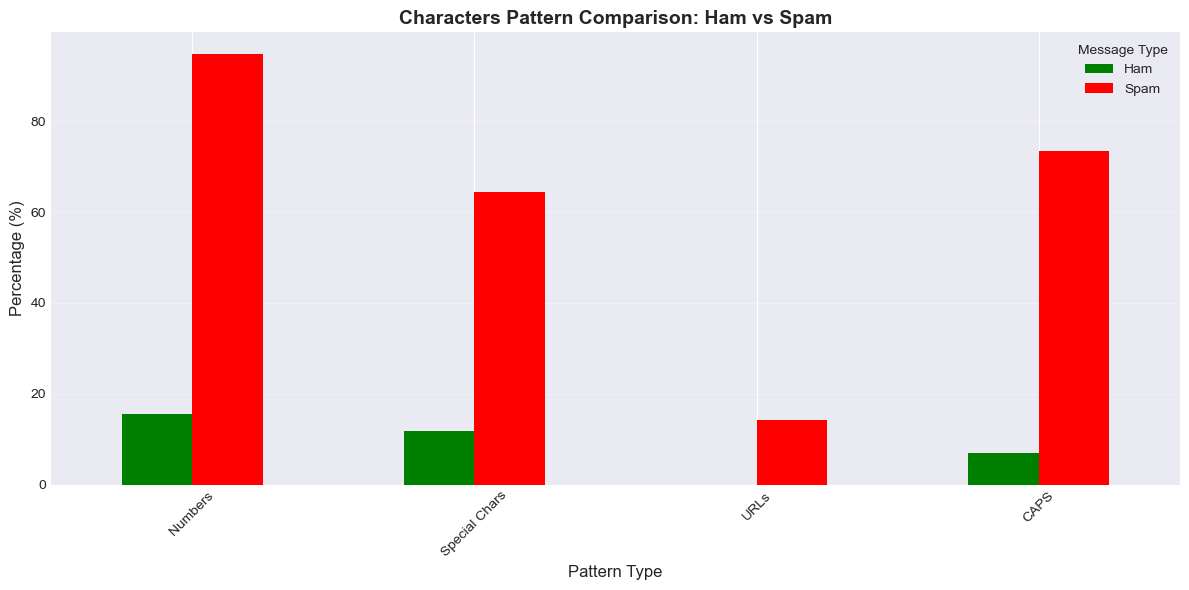

In [28]:
# Text Content Analysis
print('\n' + '=' * 70)
print('TEXT CONTENT ANALYSIS')
print('=' * 70 + '\n')

# Sample messages
print('SAMPLE HAM MESSAGES:')
ham_samples = spam[spam['label'] == 'ham']['message'].head()
for i, msg in enumerate(ham_samples, 1):
    print(f"{i}. {msg[:100]}..." if len(msg) > 100 else f"{i}. {msg}")
    print()

print('SAMPLE SPAM MESSAGES:')
spam_samples = spam[spam['label'] == 'spam']['message'].head()
for i, msg in enumerate(spam_samples, 1):
    print(f"{i}. {msg[:100]}..." if len(msg) > 100 else f"{i}. {msg}")
    print()

# Character Analysis
spam['has_numbers'] = spam['message'].str.contains(r'\d', regex = True)
spam['has_special_chars'] = spam['message'].str.contains(r'[!$£€]', regex = True)
spam['has_url'] = spam['message'].str.contains(r'http|www', case = False, regex = True)
spam['has_caps'] = spam['message'].str.contains(r'[A-Z]{3,}', regex = True)

print('CHARACTER PATTERNS BY TYPE:')
print('\nHAM MESSAGES:')
print(f"Contains numbers: {spam[spam['label'] == 'ham']['has_numbers'].sum()} ({spam[spam['label'] == 'ham']['has_numbers'].mean() * 100:.1f}%)")
print(f"Contains special chars (!$£€): {spam[spam['label'] == 'ham']['has_special_chars'].sum()} ({spam[spam['label'] == 'ham']['has_special_chars'].mean() * 100:.1f}%)")
print(f"Contains URLs: {spam[spam['label'] == 'ham']['has_url'].sum()} ({spam[spam['label'] == 'ham']['has_url'].mean() * 100:.1f}%)")
print(f"Contains CAPS (3+): {spam[spam['label'] == 'ham']['has_caps'].sum()} ({spam[spam['label'] == 'ham']['has_caps'].mean() * 100:.1f}%)")

print('\nSPAM MESSAGES:')
print(f"Contains numbers: {spam[spam['label'] == 'spam']['has_numbers'].sum()}  ({spam[spam['label'] == 'spam']['has_numbers'].mean() * 100:.1f}%)")
print(f"Contains special chars (!$£€): {spam[spam['label'] == 'spam']['has_special_chars'].sum()} ({spam[spam['label'] == 'spam']['has_special_chars'].mean() * 100:.1f}%)")
print(f"Contains URLs: {spam[spam['label'] == 'spam']['has_url'].sum()} ({spam[spam['label'] == 'spam']['has_url'].mean() * 100:.1f}%)")
print(f"Contains CAPS (3+): {spam[spam['label'] == 'spam']['has_caps'].sum()} ({spam[spam['label'] == 'spam']['has_caps'].mean() * 100:.1f}%)")

# Visualization
pattern_data = pd.DataFrame({
    'Ham': [spam[spam['label'] == 'ham']['has_numbers'].mean() * 100, 
            spam[spam['label'] == 'ham']['has_special_chars'].mean() * 100,
            spam[spam['label'] == 'ham']['has_url'].mean() * 100,
            spam[spam['label'] == 'ham']['has_caps'].mean() * 100],
    'Spam':[spam[spam['label'] == 'spam']['has_numbers'].mean() * 100, 
            spam[spam['label'] == 'spam']['has_special_chars'].mean() * 100,
            spam[spam['label'] == 'spam']['has_url'].mean() * 100,
            spam[spam['label'] == 'spam']['has_caps'].mean() * 100]
}, index = ['Numbers', 'Special Chars', 'URLs', 'CAPS'])

pattern_data.plot(kind = 'bar', figsize = (12, 6), color = ['green', 'red'])
plt.title('Characters Pattern Comparison: Ham vs Spam', fontsize = 14, fontweight = 'bold')
plt.xlabel('Pattern Type', fontsize = 12)
plt.ylabel('Percentage (%)', fontsize = 12)
plt.xticks(rotation = 45)
plt.legend(title = 'Message Type')
plt.grid(axis = 'y', alpha = 0.3)
plt.tight_layout()
plt.show()


WORD CLOUD VISUALIZATION



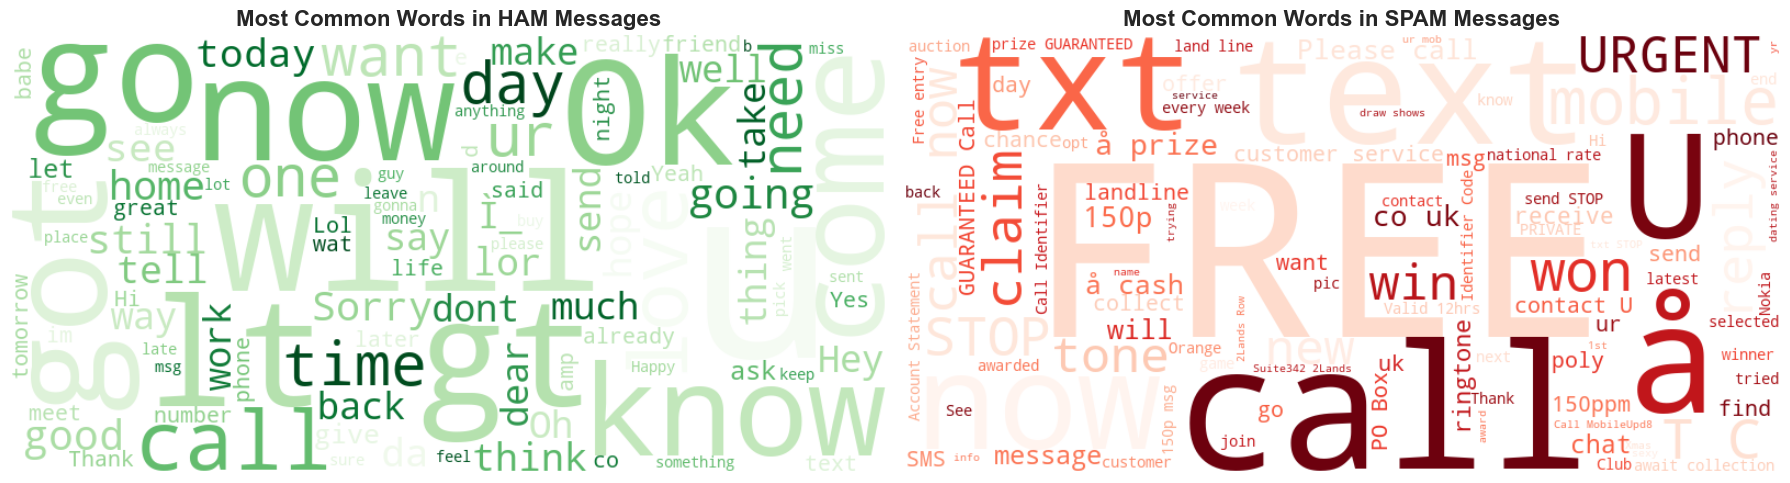

Word clouds generated successfully


In [30]:
# Word Cloud Visualization
print('\n' + '=' * 70)
print('WORD CLOUD VISUALIZATION')
print('=' * 70 + '\n')

try:
    from wordcloud import WordCloud, STOPWORDS

    # Prepare text
    ham_text = ' '.join(spam[spam['label'] == 'ham']['message'].values)
    spam_text = ' '.join(spam[spam['label'] == 'spam']['message'].values)

    # Create word clouds
    fig, axes = plt.subplots(1, 2, figsize = (18, 8))

    # Ham word cloud
    wordcloud_ham = WordCloud(width = 800, height = 400, background_color = 'white', stopwords = STOPWORDS, 
                              colormap = 'Greens', max_words = 100).generate(ham_text)
    axes[0].imshow(wordcloud_ham, interpolation = 'bilinear')
    axes[0].set_title('Most Common Words in HAM Messages', fontsize = 16, fontweight = 'bold')
    axes[0].axis('off')

    # Spam word cloud
    wordcloud_spam = WordCloud(width = 800, height = 400, background_color = 'white', stopwords = STOPWORDS,
                               colormap = 'Reds', max_words = 100).generate(spam_text)
    axes[1].imshow(wordcloud_spam, interpolation = 'bilinear')
    axes[1].set_title('Most Common Words in SPAM Messages', fontsize = 16, fontweight = 'bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    print('Word clouds generated successfully')

except ImportError:
    print('WordCloud library not installed.')
    print('To install: pip install wordcloud')
    print('Skipping word cloud visualization...')


MOST COMMON WORDS ANALYSIS

TOP 20 WORDS IN HAM MESSAGES:
 1. get             :  305
 2. how             :  304
 3. now             :  300
 4. just            :  293
 5. when            :  287
 6. what            :  273
 7. all             :  245
 8. know            :  236
 9. call            :  236
10. then            :  233
11. good            :  233
12. got             :  232
13. like            :  232
14. come            :  227
15. its             :  221
16. there           :  216
17. out             :  214
18. day             :  209
19. time            :  201
20. love            :  199

TOP 20 WORDS IN SPAM MESSAGES:
 1. call            :  355
 2. free            :  224
 3. now             :  199
 4. txt             :  163
 5. mobile          :  127
 6. text            :  125
 7. stop            :  121
 8. claim           :  113
 9. reply           :  104
10. www             :   98
11. prize           :   93
12. get             :   86
13. our             :   85
14. only          

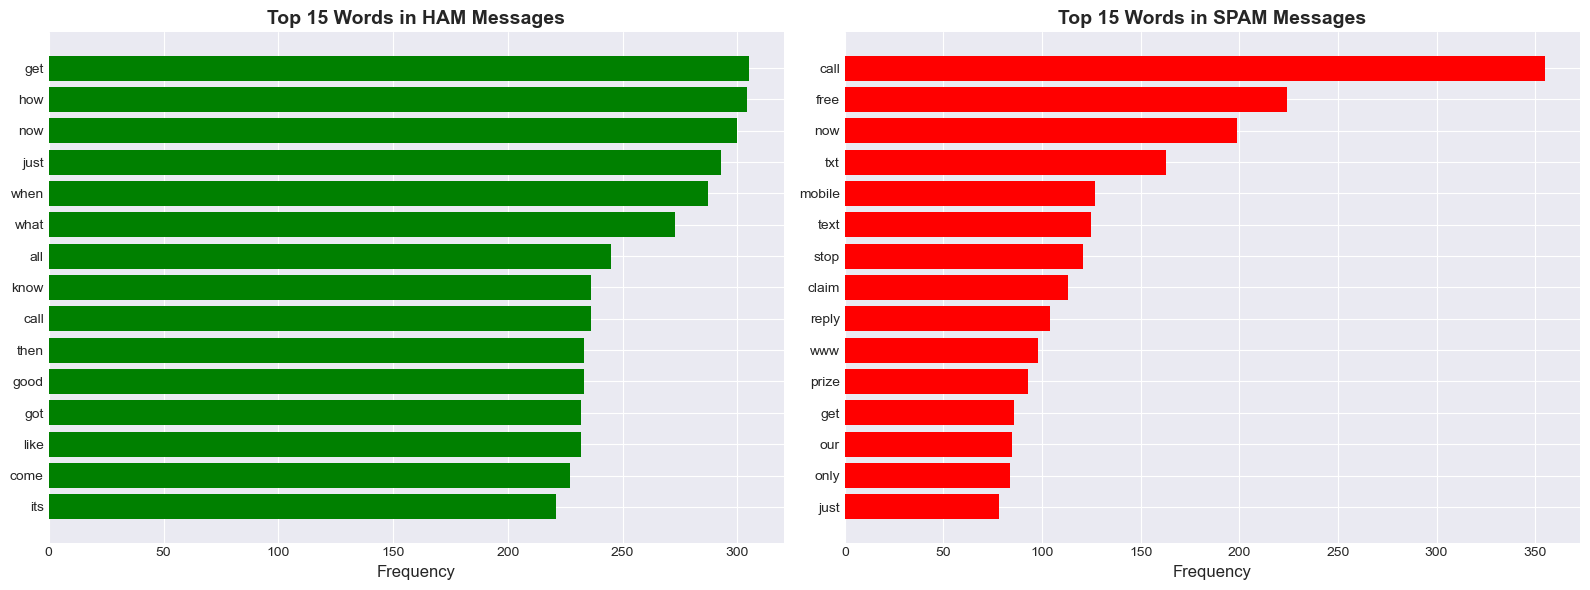

In [32]:
# Most Common Words Analysis
print('\n' + '=' * 70)
print('MOST COMMON WORDS ANALYSIS')
print('=' * 70 + '\n')

from collections import Counter
import re

def get_top_words(messages, n = 20):
    """Exact top N words from messages"""
    # Comine all messages
    all_text = ' '.join(messages)
    # Convert to lowercase and extract words
    words = re.findall(r'\b[a-z]{3,}\b', all_text.lower())
    # Remove common stopwords
    stopwords = {'the', 'and', 'to', 'of', 'for', 'you', 'in', 'is', 'that', 'it', 'on', 'with', 'was', 'are', 'this', 
                 'have', 'from', 'or', 'be', 'at', 'by', 'not', 'but', 'can', 'your', 'will', 'my', 'me', 'has'}
    words = [w for w in words if w not in stopwords]
    return Counter(words).most_common(n)

# Get top words for ham
print('TOP 20 WORDS IN HAM MESSAGES:')
ham_words = get_top_words(spam[spam['label'] == 'ham']['message'])
for i, (word, count) in enumerate(ham_words, 1):
    print(f"{i:2d}. {word:15s} : {count:4d}")

print("\nTOP 20 WORDS IN SPAM MESSAGES:")
spam_words = get_top_words(spam[spam['label'] == 'spam']['message'])
for i, (word, count) in enumerate(spam_words, 1):
    print(f"{i:2d}. {word:15s} : {count:4d}")

# Visualize top words
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Ham top words
ham_words_df = pd.DataFrame(ham_words[:15], columns = ['word', 'count'])
axes[0].barh(ham_words_df['word'], ham_words_df['count'], color = 'green')
axes[0].set_xlabel('Frequency', fontsize = 12)
axes[0].set_title('Top 15 Words in HAM Messages', fontsize = 14, fontweight = 'bold')
axes[0].invert_yaxis()

# Spam top words
spam_words_df = pd.DataFrame(spam_words[:15], columns=['word', 'count'])
axes[1].barh(spam_words_df['word'], spam_words_df['count'], color='red')
axes[1].set_xlabel('Frequency', fontsize=12)
axes[1].set_title('Top 15 Words in SPAM Messages', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [35]:
# Summary Statistics - Spam Dataset
print("\n" + "="*70)
print("SPAM DATASET - COMPREHENSIVE SUMMARY")
print("="*70 + "\n")

summary_stats_spam = {
    'Total Messages': len(spam),
    'Ham Messages': (spam['label'] == 'ham').sum(),
    'Spam Messages': (spam['label'] == 'spam').sum(),
    'Spam Rate': f"{((spam['label'] == 'spam').sum() / len(spam) * 100):.2f}%",
    'Avg Message Length (Ham)': f"{spam[spam['label']=='ham']['message_length'].mean():.1f} chars",
    'Avg Message Length (Spam)': f"{spam[spam['label']=='spam']['message_length'].mean():.1f} chars",
    'Avg Word Count (Ham)': f"{spam[spam['label']=='ham']['word_count'].mean():.1f} words",
    'Avg Word Count (Spam)': f"{spam[spam['label']=='spam']['word_count'].mean():.1f} words",
    'Duplicate Messages': spam.duplicated().sum(),
    'Class Balance Ratio': f"{(spam['label']=='ham').sum() / (spam['label']=='spam').sum():.2f}:1"
}

print("KEY METRICS:")
for key, value in summary_stats_spam.items():
    print(f"{key}: {value}")


SPAM DATASET - COMPREHENSIVE SUMMARY

KEY METRICS:
Total Messages: 5572
Ham Messages: 4825
Spam Messages: 747
Spam Rate: 13.41%
Avg Message Length (Ham): 71.0 chars
Avg Message Length (Spam): 138.9 chars
Avg Word Count (Ham): 14.2 words
Avg Word Count (Spam): 23.9 words
Duplicate Messages: 403
Class Balance Ratio: 6.46:1


In [36]:
# Key Findins & Insights - Spam Dataset
print("\n" + "="*70)
print("KEY FINDINGS & INSIGHTS - SPAM DATASET")
print("="*70 + "\n")

print("DATA QUALITY:")
print(f"Clean dataset with no missing values")
print(f"{spam.duplicated().sum()} duplicate messages found")
print(f"Dataset has {len(spam):,} messages total")
print()

print("CLASS DISTRIBUTION:")
ham_pct = (spam['label']=='ham').sum() / len(spam) * 100
spam_pct = (spam['label']=='spam').sum() / len(spam) * 100
print(f"Ham: {ham_pct:.1f}% ({(spam['label']=='ham').sum():,} messages)")
print(f"Spam: {spam_pct:.1f}% ({(spam['label']=='spam').sum():,} messages)")
if abs(ham_pct - spam_pct) > 50:
    print(f"Highly imbalanced! Ham is {ham_pct/spam_pct:.1f}x more common")
else:
    print(f"Reasonably balanced distribution")
print()

print("MESSAGE LENGTH PATTERNS:")
ham_avg = spam[spam['label']=='ham']['message_length'].mean()
spam_avg = spam[spam['label']=='spam']['message_length'].mean()
print(f"Ham messages: avg {ham_avg:.0f} characters")
print(f"Spam messages: avg {spam_avg:.0f} characters")
if spam_avg > ham_avg:
    print(f"Spam messages are {((spam_avg/ham_avg - 1)*100):.1f}% longer")
else:
    print(f"Ham messages are {((ham_avg/spam_avg - 1)*100):.1f}% longer")
print()

print("DISTINCTIVE FEATURES:")
spam_numbers = spam[spam['label']=='spam']['has_numbers'].mean() * 100
ham_numbers = spam[spam['label']=='ham']['has_numbers'].mean() * 100
print(f"Numbers more common in {'spam' if spam_numbers > ham_numbers else 'ham'} ({max(spam_numbers, ham_numbers):.1f}% vs {min(spam_numbers, ham_numbers):.1f}%)")

spam_special = spam[spam['label']=='spam']['has_special_chars'].mean() * 100
ham_special = spam[spam['label']=='ham']['has_special_chars'].mean() * 100
print(f"Special chars (!$£€) more in {'spam' if spam_special > ham_special else 'ham'} ({max(spam_special, ham_special):.1f}% vs {min(spam_special, ham_special):.1f}%)")

spam_caps = spam[spam['label']=='spam']['has_caps'].mean() * 100
ham_caps = spam[spam['label']=='ham']['has_caps'].mean() * 100
print(f"CAPITAL letters more in {'spam' if spam_caps > ham_caps else 'ham'} ({max(spam_caps, ham_caps):.1f}% vs {min(spam_caps, ham_caps):.1f}%)")
print()

print("CONTENT PATTERNS:")
print(f"Spam often contains: 'free', 'win', 'call', 'prize', 'urgent'")
print(f"Ham often contains: casual conversation words")


KEY FINDINGS & INSIGHTS - SPAM DATASET

DATA QUALITY:
Clean dataset with no missing values
403 duplicate messages found
Dataset has 5,572 messages total

CLASS DISTRIBUTION:
Ham: 86.6% (4,825 messages)
Spam: 13.4% (747 messages)
Highly imbalanced! Ham is 6.5x more common

MESSAGE LENGTH PATTERNS:
Ham messages: avg 71 characters
Spam messages: avg 139 characters
Spam messages are 95.5% longer

DISTINCTIVE FEATURES:
Numbers more common in spam (94.8% vs 15.5%)
Special chars (!$£€) more in spam (64.4% vs 11.9%)
CAPITAL letters more in spam (73.5% vs 7.1%)

CONTENT PATTERNS:
Spam often contains: 'free', 'win', 'call', 'prize', 'urgent'
Ham often contains: casual conversation words


In [37]:
# Saved Processed Spam Data
print("\n" + "="*70)
print("SAVE PROCESSED DATA")
print("="*70 + "\n")

# Save cleaned dataset
output_path_spam = '../data/processed/spam_explored.csv'

try:
    spam.to_csv(output_path_spam, index=False)
    print(f"Cleaned spam dataset saved to: {output_path_spam}")
    print(f"Columns: {list(spam.columns)}")
    print(f"Shape: {spam.shape}")
except Exception as e:
    print(f"Could not save file: {e}")

print("\n" + "="*70)
print("SPAM DATASET EXPLORATION COMPLETE!")
print("="*70)
print("\nDataset Summary:")
print(f"{len(spam):,} total messages")
print(f"{(spam['label']=='spam').sum():,} spam messages")
print(f"{(spam['label']=='ham').sum():,} ham messages")
print(f"{len(spam.columns)} features created")


SAVE PROCESSED DATA

Cleaned spam dataset saved to: ../data/processed/spam_explored.csv
Columns: ['label', 'message', 'message_length', 'word_count', 'has_numbers', 'has_special_chars', 'has_url', 'has_caps']
Shape: (5572, 8)

SPAM DATASET EXPLORATION COMPLETE!

Dataset Summary:
5,572 total messages
747 spam messages
4,825 ham messages
8 features created
